# 03 — As anomalias do modelo sobre a série temporal

Os notebooks anteriores mostram *o que existe* — a série e as falhas (01) — e *qual
configuração rende mais detecção por falso positivo* (02). Este responde à pergunta
que se faz olhando um gráfico:

> **onde o modelo marcou anomalia, onde a máquina realmente caiu, e o que ele
> acertou, errou ou deixou passar?**

O formato é o dos notebooks de anomalia do projeto `Transpetro-modelos`
(`notebooks/*/plot_anomalias.ipynb`): a leitura do sensor em azul, os instantes de
anomalia em vermelho **sobre a própria leitura**, e a falha real como linha
vertical laranja tracejada.

Três coisas são diferentes aqui, e mudam a figura:

| No Transpetro | Aqui |
|---|---|
| limiar fixo, calibrado uma vez | **limiar do mês** — percentil do baseline daquele mês, então é uma linha em escada |
| um sinal (erro de reconstrução) | **três sinais** (temperatura, pressão/óleo, spread do mancal) e o alerta exige vários simultâneos |
| equipamento praticamente sempre ligado | máquina **parada boa parte do tempo** — sem operação não há score, e as paradas aparecem sombreadas em cinza |

O cálculo não é reimplementado: `cabiunas_pdm.replay` importa as próprias classes
de `scripts/automl_clearml.py` e apenas **guarda as séries** em vez de só as
métricas. No fim de cada execução o replay é conferido contra o avaliador do
AutoML — se divergir em um evento ou em um falso positivo, levanta erro. Confere
também com a task remota: a configuração campeã dá aqui os mesmos
`2/6 eventos, 23,9 h, 0,77 FP/mês` da linha 7984 da grade da task
`cef5fc8f16034eccac95bbb30b6f1814` — **a mesma task do notebook 02**: lá se vê a
grade inteira (10.368 configurações), aqui se vê a campeã dela em funcionamento.

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore")
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))

from cabiunas_pdm import viz
from cabiunas_pdm.replay import DetectionReplay, load_alarms

viz.usar_estilo()

# Campeãs da task 61b6b109896d4b618fd975216d06c25c (31.104 configurações, com o
# baseline acumulativo como dimensão nova). Escolhidas pela fronteira COM exigência
# de antecedência — sem isso a busca prefere pontos que avisam com 6 h, o que não
# serve para programar intervenção.
#
# OPERACIONAL: 5 de 8 falhas, 17,9 h de antecedência, 0,77 FP/mês (0,51 líquido).
# É o melhor resultado do projeto até agora.
OPERACIONAL = dict(model="pca", grid="2min", baseline_hours=300,
                   baseline_mode="acumulativo", exclude_days=0, exclude_alarm_h=1.0,
                   ewma="2h", threshold=99.9, sustain="30min", confirm=2,
                   min_alert="0min")
# CONSERVADOR: 2 de 8, mas 24,4 h de antecedência e só 0,7 h/mês de alarme falso.
# Note que aqui o baseline volta a ser MÓVEL — acima de 24 h de horizonte o
# acumulativo perde.
CONSERVADOR = dict(model="ae", grid="30s", baseline_hours=300, baseline_mode="movel",
                   exclude_days=0, exclude_alarm_h=1.0, ewma="30min", threshold=99.5,
                   sustain="1h", confirm=4, min_alert="30min")

replay = DetectionReplay(max_fp_per_month=1.0)
resultado = replay.run(**CONSERVADOR)
pd.Series(resultado.metrics).to_frame("valor")

[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_ae_30s_300h_0_1.0_809a6e47.pkl


[replay] ae|30s|b300h|excl0d|alm1.0h|ewma30min|q99.5|sust1h|conf4|min30min -> 2/8 eventos | lead 24.4 h | FP 0.77/mês


,valor
eventos_detectados,2
eventos_total,8
lead_medio_h,24.4
fp_episodios,9
fp_por_mes,0.77
dias_avaliados,348.6
episodios_totais,14
baseline_amostras,36000
fp_horas_por_mes,0.7
aprovado,True


## 1. O período completo

Um painel por sinal, mais o painel de confirmação, no mesmo eixo de tempo
(jan/2025 → abr/2026). Em cada painel de score:

* **linha roxa** — o score do sinal;
* **linha vermelha tracejada** — o limite daquele mês, e a **área vermelha** é o
  quanto o score passou dele;
* **ponto laranja** — cruzou o limite mas ainda não sustentou o tempo exigido;
* **ponto vermelho** — cruzou **e** sustentou (o sinal passa a contar para a
  confirmação);
* **linha laranja vertical** — falha real; **cinza de fundo** — máquina parada.

No painel de baixo, quantos sinais estão sustentados ao mesmo tempo: o alerta só
existe quando a contagem alcança a linha vermelha. Os triângulos no topo são os
episódios de alerta, separados em três categorias (antecipou falha catalogada /
veio antes de uma parada não catalogada / falso positivo).

Só nesta figura o score aparece **dividido pelo limite do mês** (o limite vira a
reta 1,0), com eixo logarítmico. É o único desvio do padrão do Transpetro, e por
um motivo concreto: em 16 meses com re-baseline mensal, um pico de 63 mil na
unidade crua achata todo o resto da série. Nos zooms por evento — uma janela, um
limite — o score aparece na unidade original.

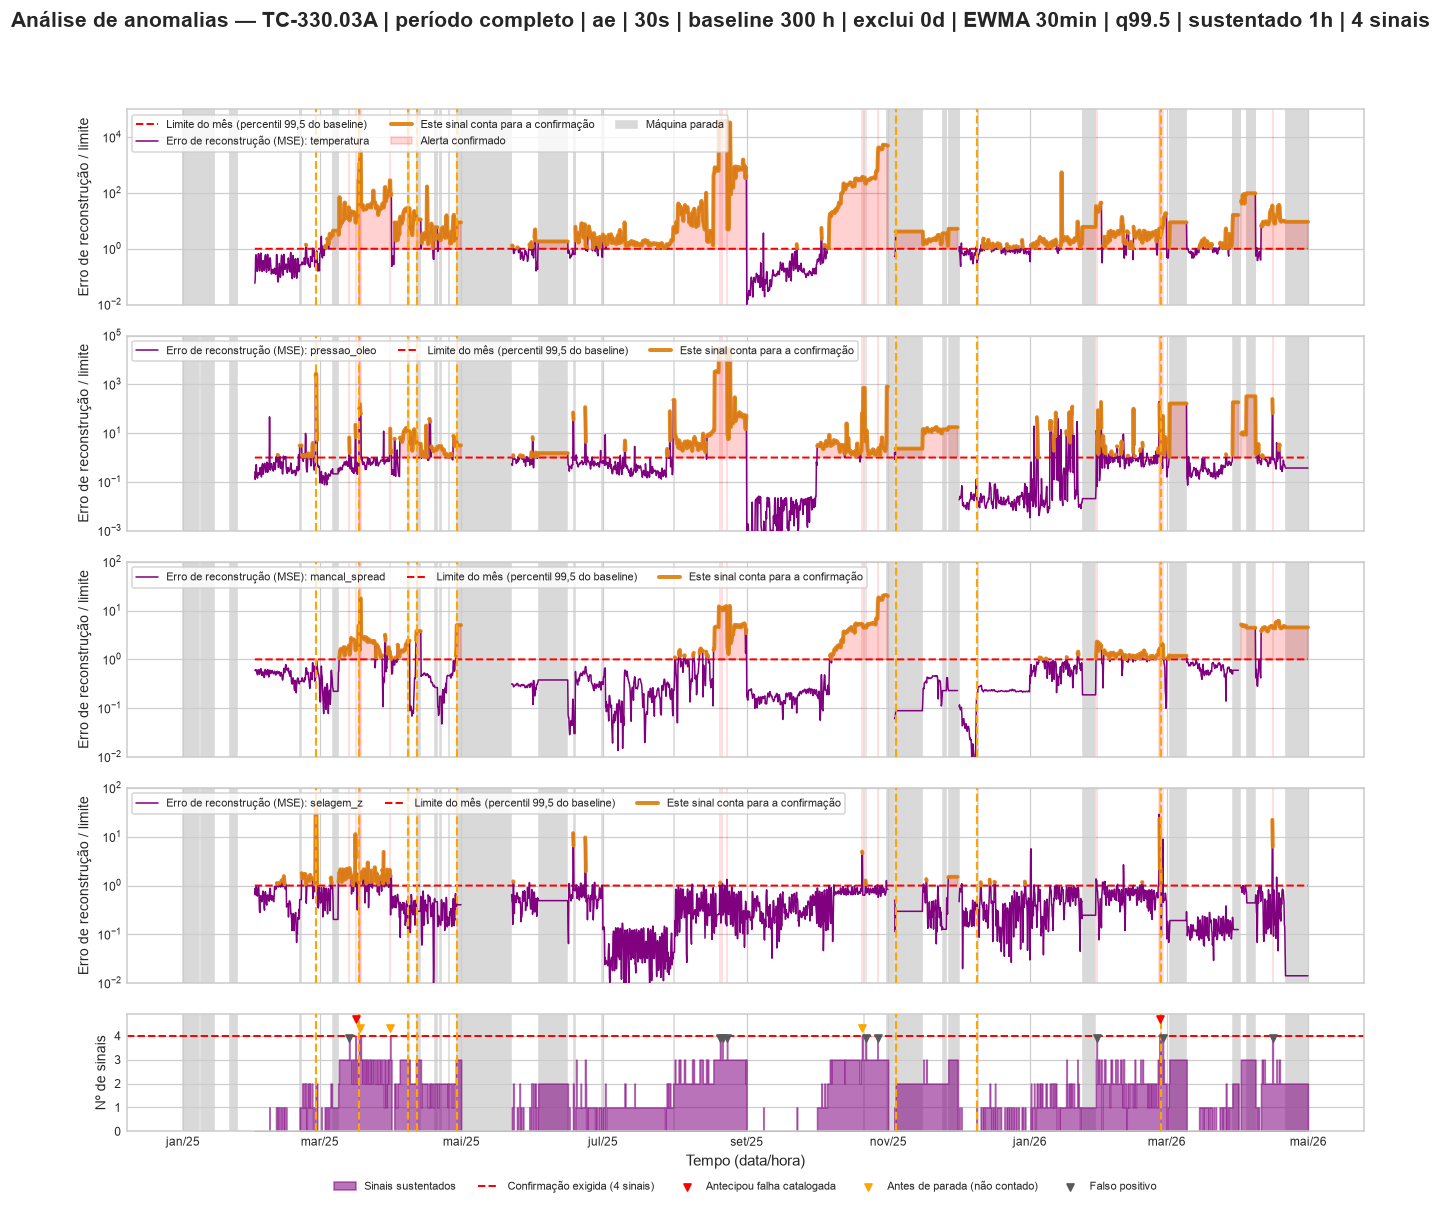

In [2]:
viz.plot_periodo(resultado);

### O que essa figura já diz

Os três sinais **não sobem juntos**: o painel de baixo passa muito tempo em 1 ou
2 sinais e raramente alcança 3. É exatamente por isso que a política exige
confirmação múltipla — e a seção seguinte mostra o tamanho real desse efeito, que
é maior do que parece.

## 1b. O score e os limiares

A figura acima mostra o score **no tempo**. Esta mostra o score **como
distribuição**, que é onde dá para ver o que o limiar significa: onde ele cai
dentro da massa de dados e quanto do tempo fica acima dele.

O limite é o percentil 99,99 do baseline daquele mês — por construção, apenas
0,01% do **baseline** fica acima. São 15 meses, então há 15 limites: o feixe de
linhas tracejadas. A linha vermelha cheia é a mediana deles.

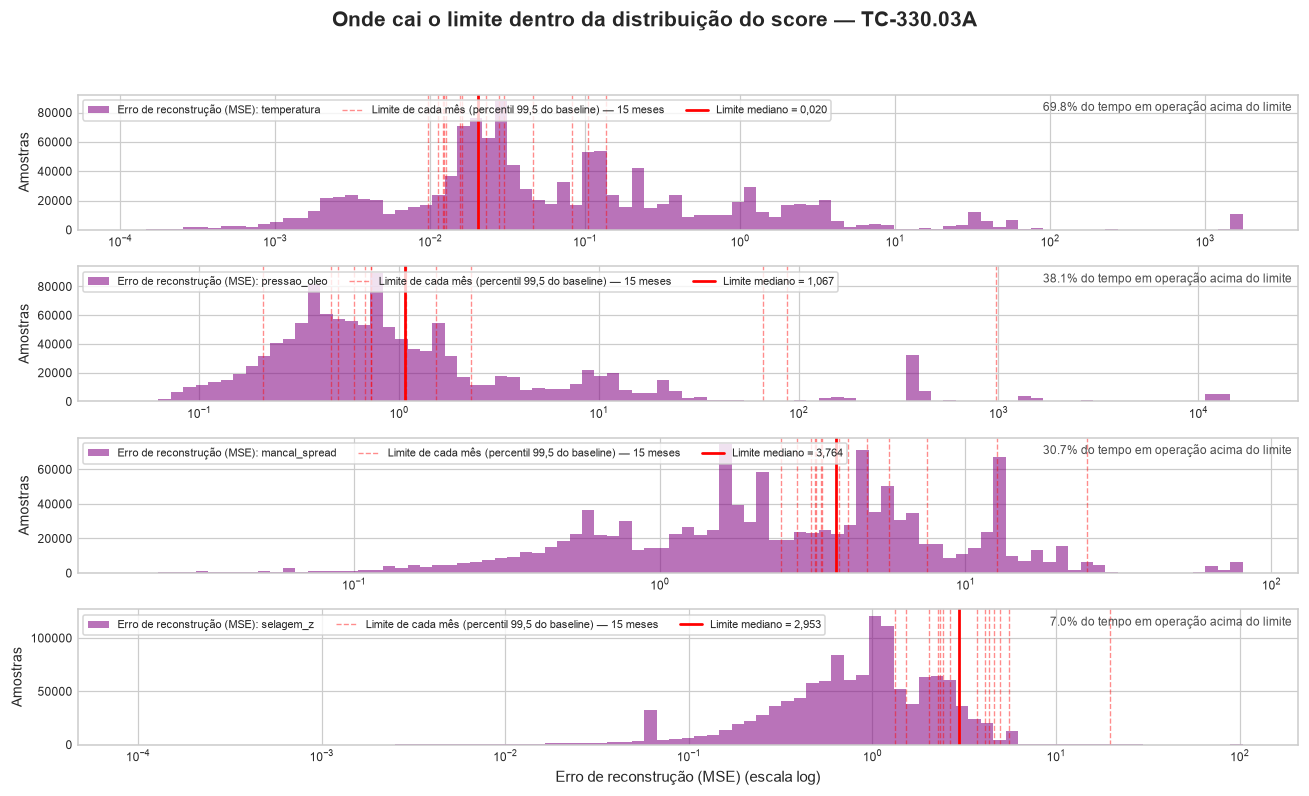

In [3]:
viz.plot_limiares(resultado);

In [4]:
# quanto de cada etapa sobra: cruzar o limite → sustentar → confirmar com 3 sinais
em_operacao = resultado.scores.iloc[:, 0].notna()
etapas = pd.DataFrame({
    "acima do limite": (resultado.scores > resultado.limits)[em_operacao].mean(),
    "…e sustentado": resultado.flags[em_operacao].mean(),
    "limite mediano": resultado.limits.median(),
    "score mediano": resultado.scores.median(),
}).round(3)
etapas.loc["alerta confirmado (3 sinais)", "…e sustentado"] = round(
    float(resultado.alert[em_operacao].mean()), 3)
etapas

,acima do limite,…e sustentado,limite mediano,score mediano
temperatura,0.698,0.684,0.020,0.037
pressao_oleo,0.381,0.365,1.067,0.754
mancal_spread,0.307,0.300,3.764,2.346
selagem_z,0.070,0.060,2.953,0.944
alerta confirmado (3 sinais),NaN,0.004,NaN,NaN


### O que isso muda na leitura

Aqui está o fato mais desconfortável do projeto, e ele só aparece nesta figura:

**um limite que deixa 0,01% do baseline acima dele deixa quase metade do mês
seguinte acima.** Temperatura fica **48,8%** do tempo em operação acima do seu
limite; spread do mancal, 32,7%; pressão/óleo, 16,7%. Ou seja: o "normal"
aprendido em 28 dias **não vale** para o mês seguinte — a deriva entre meses é
muito maior que a dispersão dentro do baseline.

Duas consequências práticas:

1. **O que segura o falso positivo não é o limiar** — é a exigência de **3 sinais
   simultâneos**, que derruba de ~49% para **5% do tempo em operação**, e depois o
   agrupamento em episódios (alertas a menos de 2 h contam como um), que transforma
   esses 5% em **17 episódios** no período todo. O limiar sozinho seria inútil.
2. **É o argumento mais forte para o resíduo condicionado à carga.** Boa parte
   dessa deriva é mudança de regime de operação, não degradação. Enquanto o modelo
   não souber em que ponto de carga a máquina está (`NGP_A`, ausente nesta versão
   do dataset), ele vai continuar chamando "mudança de carga" de "anomalia" — e
   pagando por isso com o teto de detecção.

Se quiser ver os mesmos scores na unidade crua em vez de divididos pelo limite:
`viz.plot_periodo(resultado, normalizar=False)`.

## 2. O placar: acertou, perdeu, alarmou à toa

À esquerda, cada falha real e a antecedência do alerta (barra vermelha = falha
antecipada; barra vazia = falha que passou sem alerta nas 48 h anteriores). À
direita, o balanço geral, incluindo o custo em falsos positivos.

Na tabela, `operou_nas_48h` diz quantas das 48 h anteriores a máquina passou
ligada. Serve para separar "o modelo perdeu" de "não havia janela para ver".

,falha,mecanismo,detectada,antecedencia_h,primeiro_alerta,operou_nas_48h,trips
0,2025-02-27 08:38:00,selagem,False,NaN,NaT,48.0,1
1,2025-03-17 18:16:00,mancal,True,29.8,2025-03-16 12:28:00,48.0,2
2,2025-04-07 21:18:00,mancal,False,NaN,NaT,47.6,1
3,2025-04-11 17:04:00,mancal,False,NaN,NaT,48.0,1
4,2025-04-29 03:04:00,mancal,False,NaN,NaT,47.8,1
5,2025-11-04 06:22:00,oleo,False,NaN,NaT,15.3,1
6,2025-12-09 08:36:00,mancal,False,NaN,NaT,47.8,1
7,2026-02-26 15:34:00,oleo,True,18.9,2026-02-25 20:40:30,48.0,1


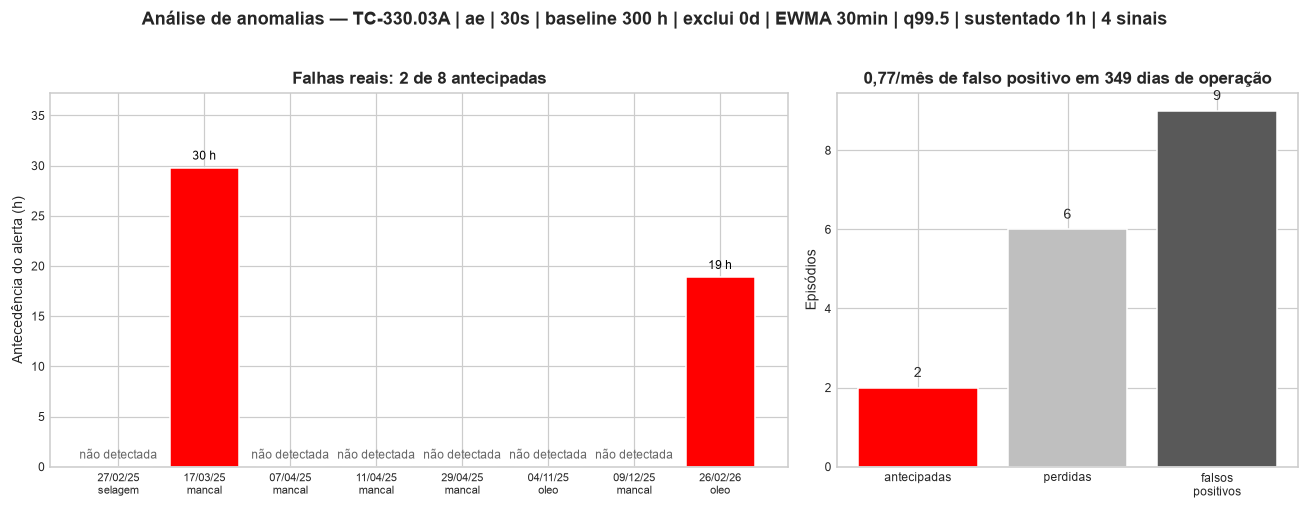

In [5]:
viz.plot_placar(resultado)
resultado.events_table()

## 3. Cada falha de perto

Uma figura por falha real, no formato do `plot_anomalias.ipynb` do Transpetro:
primeiro os sensores do mecanismo daquela falha (série em azul, **anomalia em
vermelho sobre a própria leitura**), depois um painel de score por sinal (roxo,
limite do mês em vermelho tracejado, área excedente preenchida, cruzamento bruto
em laranja e sinal com persistência em vermelho), e por último quantos sinais
estavam sustentados.

Nos painéis de sensor o vermelho marca o **alerta confirmado** — a decisão final,
com todos os sinais exigidos. Nos painéis de score o vermelho é por sinal: mostra
qual sinal estava contribuindo em cada momento.

Quando um sensor salta para o fim de escala no instante do trip (termopar de
mancal indo a centenas de graus, por exemplo), o eixo é cortado nos percentis
0,2–99,8 e o pico é anotado. É o segundo desvio deliberado: sem o recorte, o salto
domina o eixo e a subida que **antecede** a falha, que é o objeto da análise,
desaparece.

`viz.plot_evento(..., modo="separado")` devolve uma figura por painel, como o modo
`separated` do Transpetro, se for melhor para colar em slide.

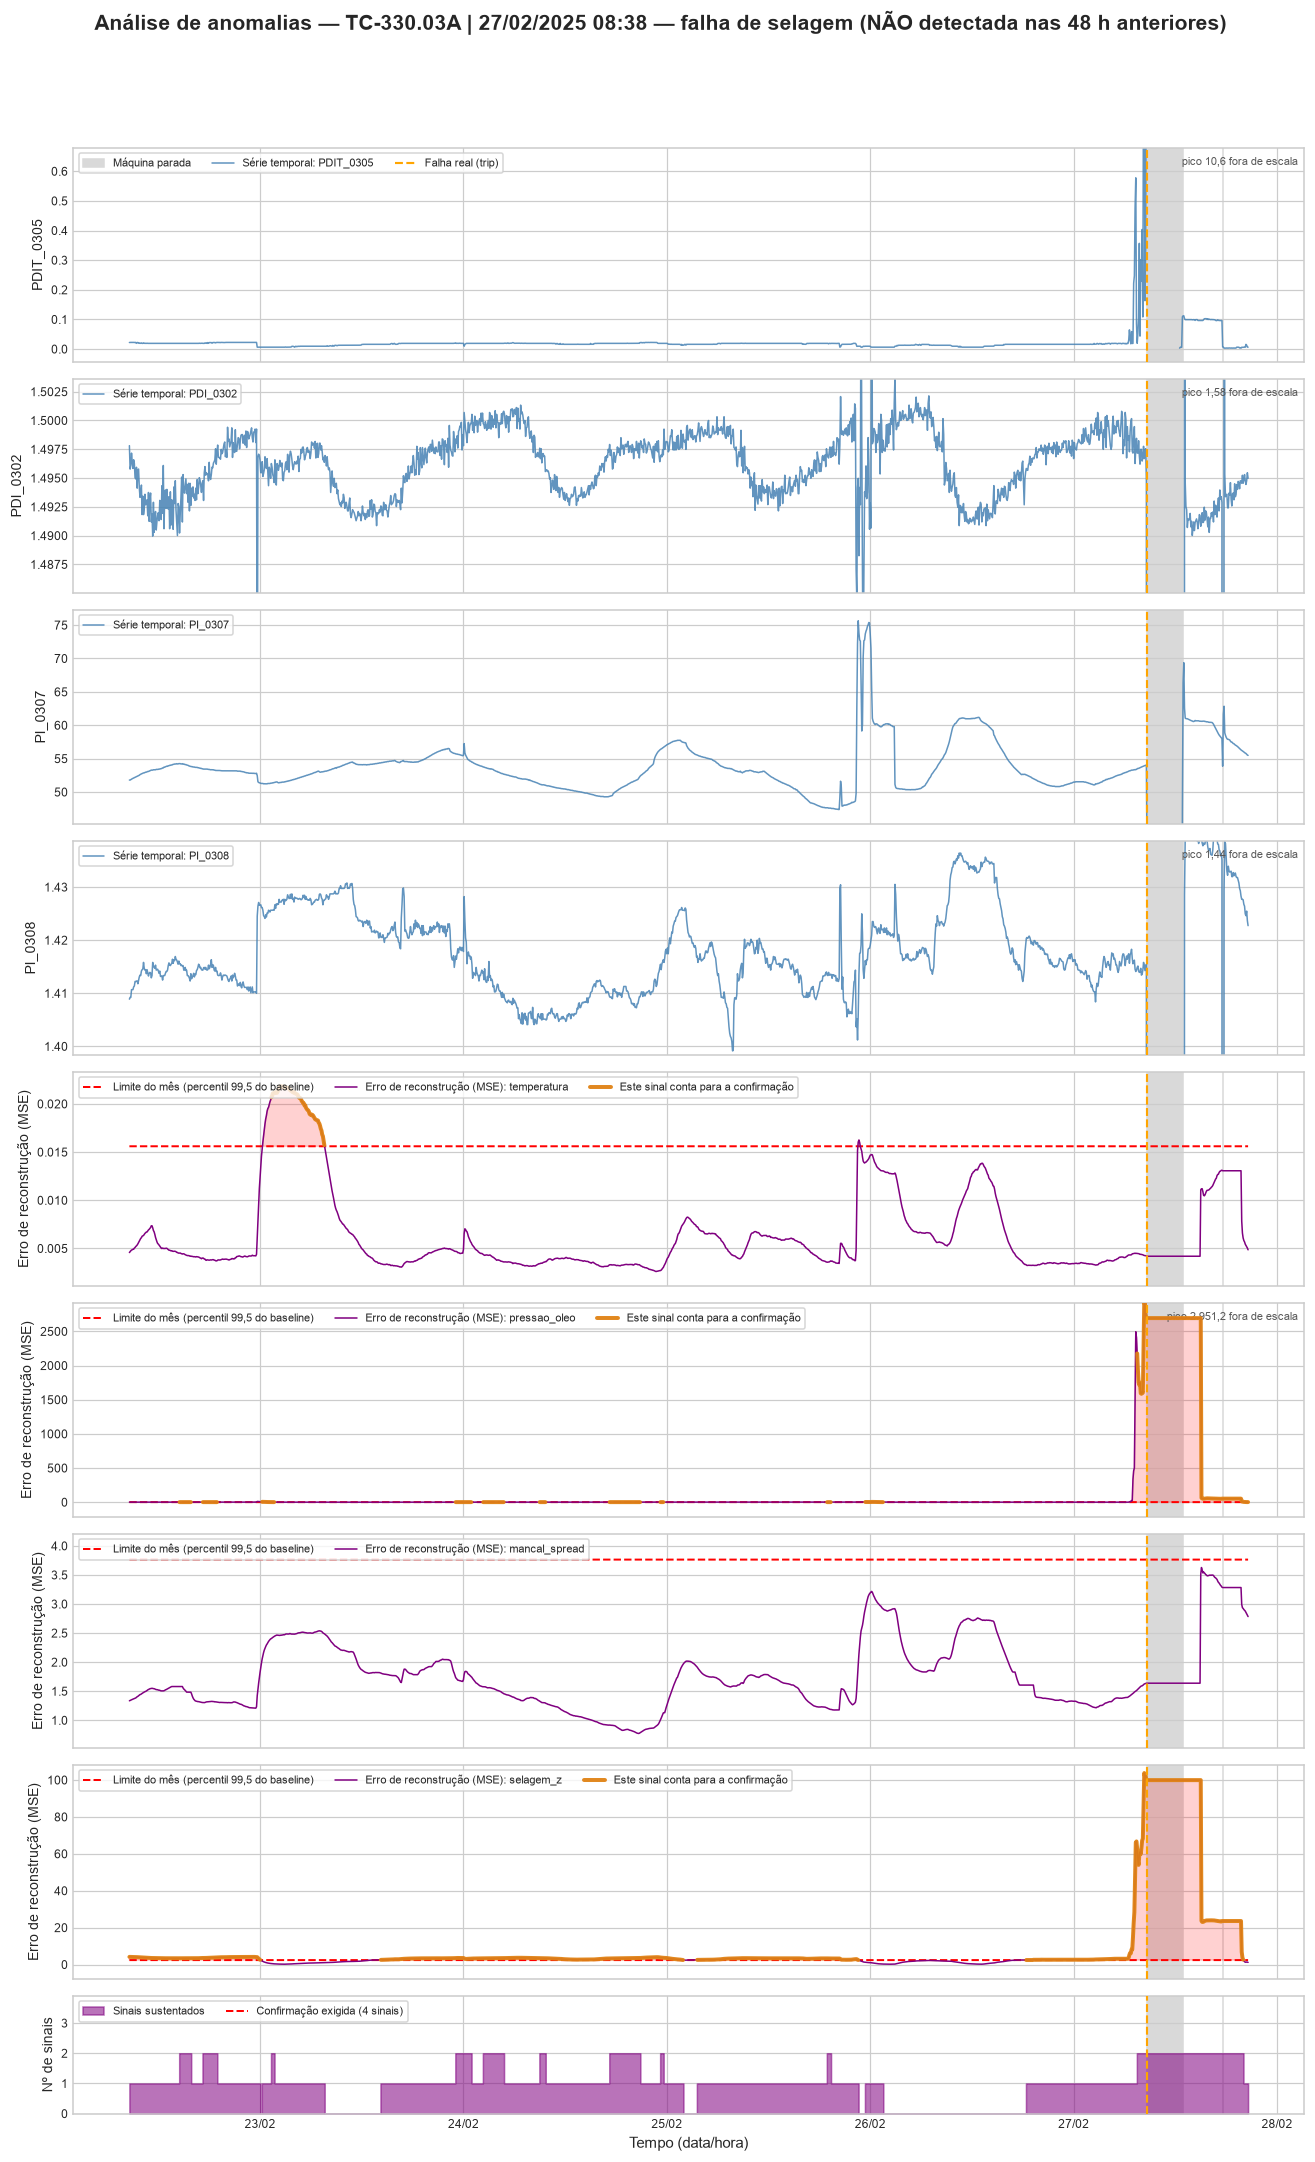

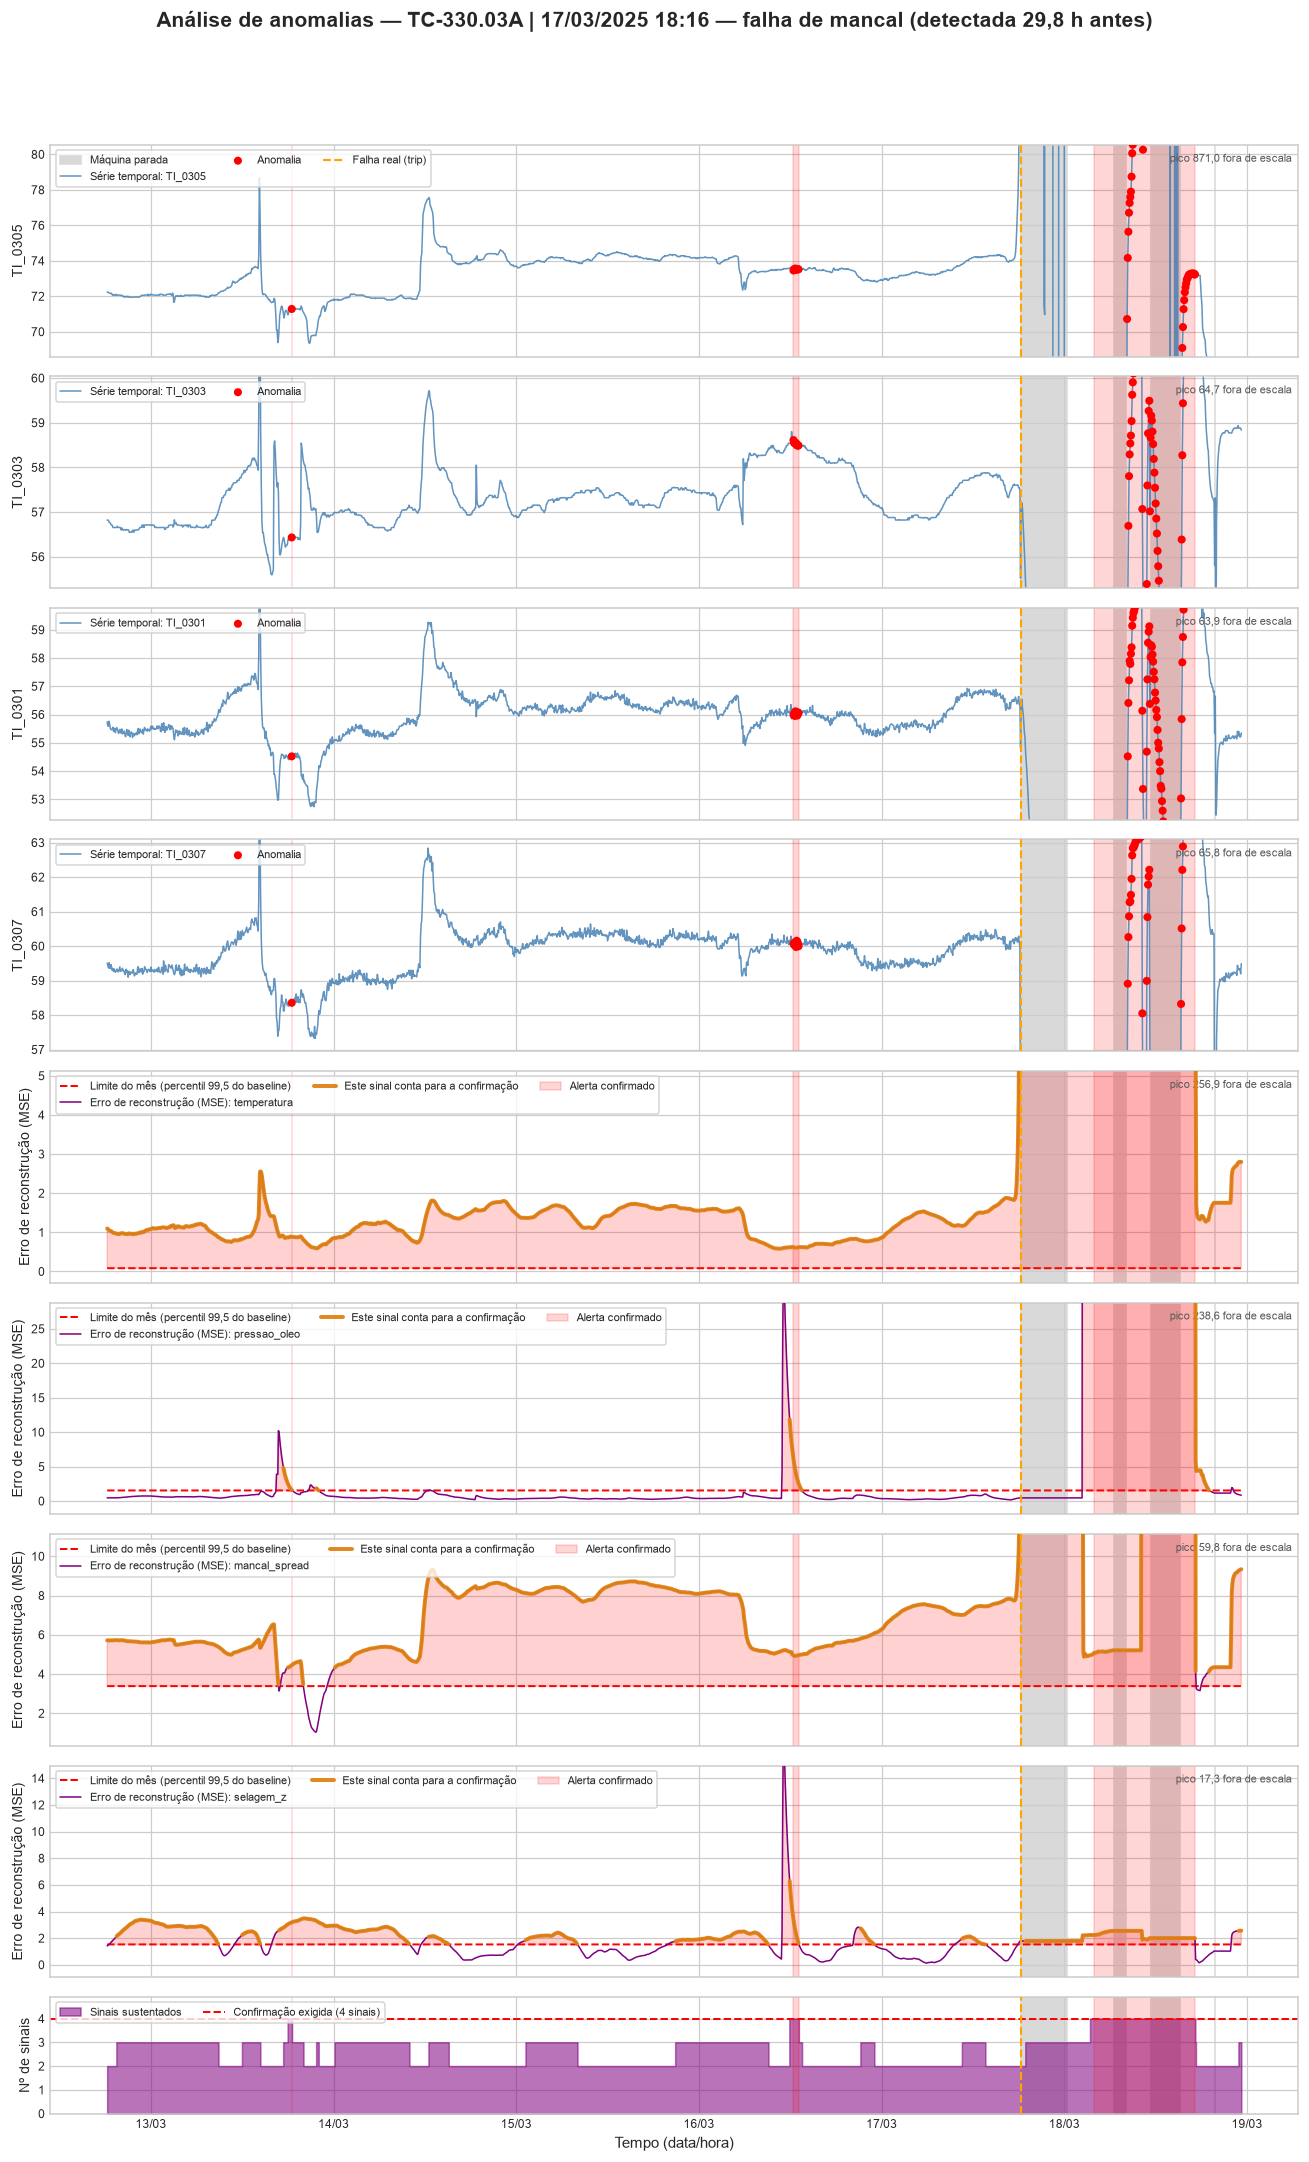

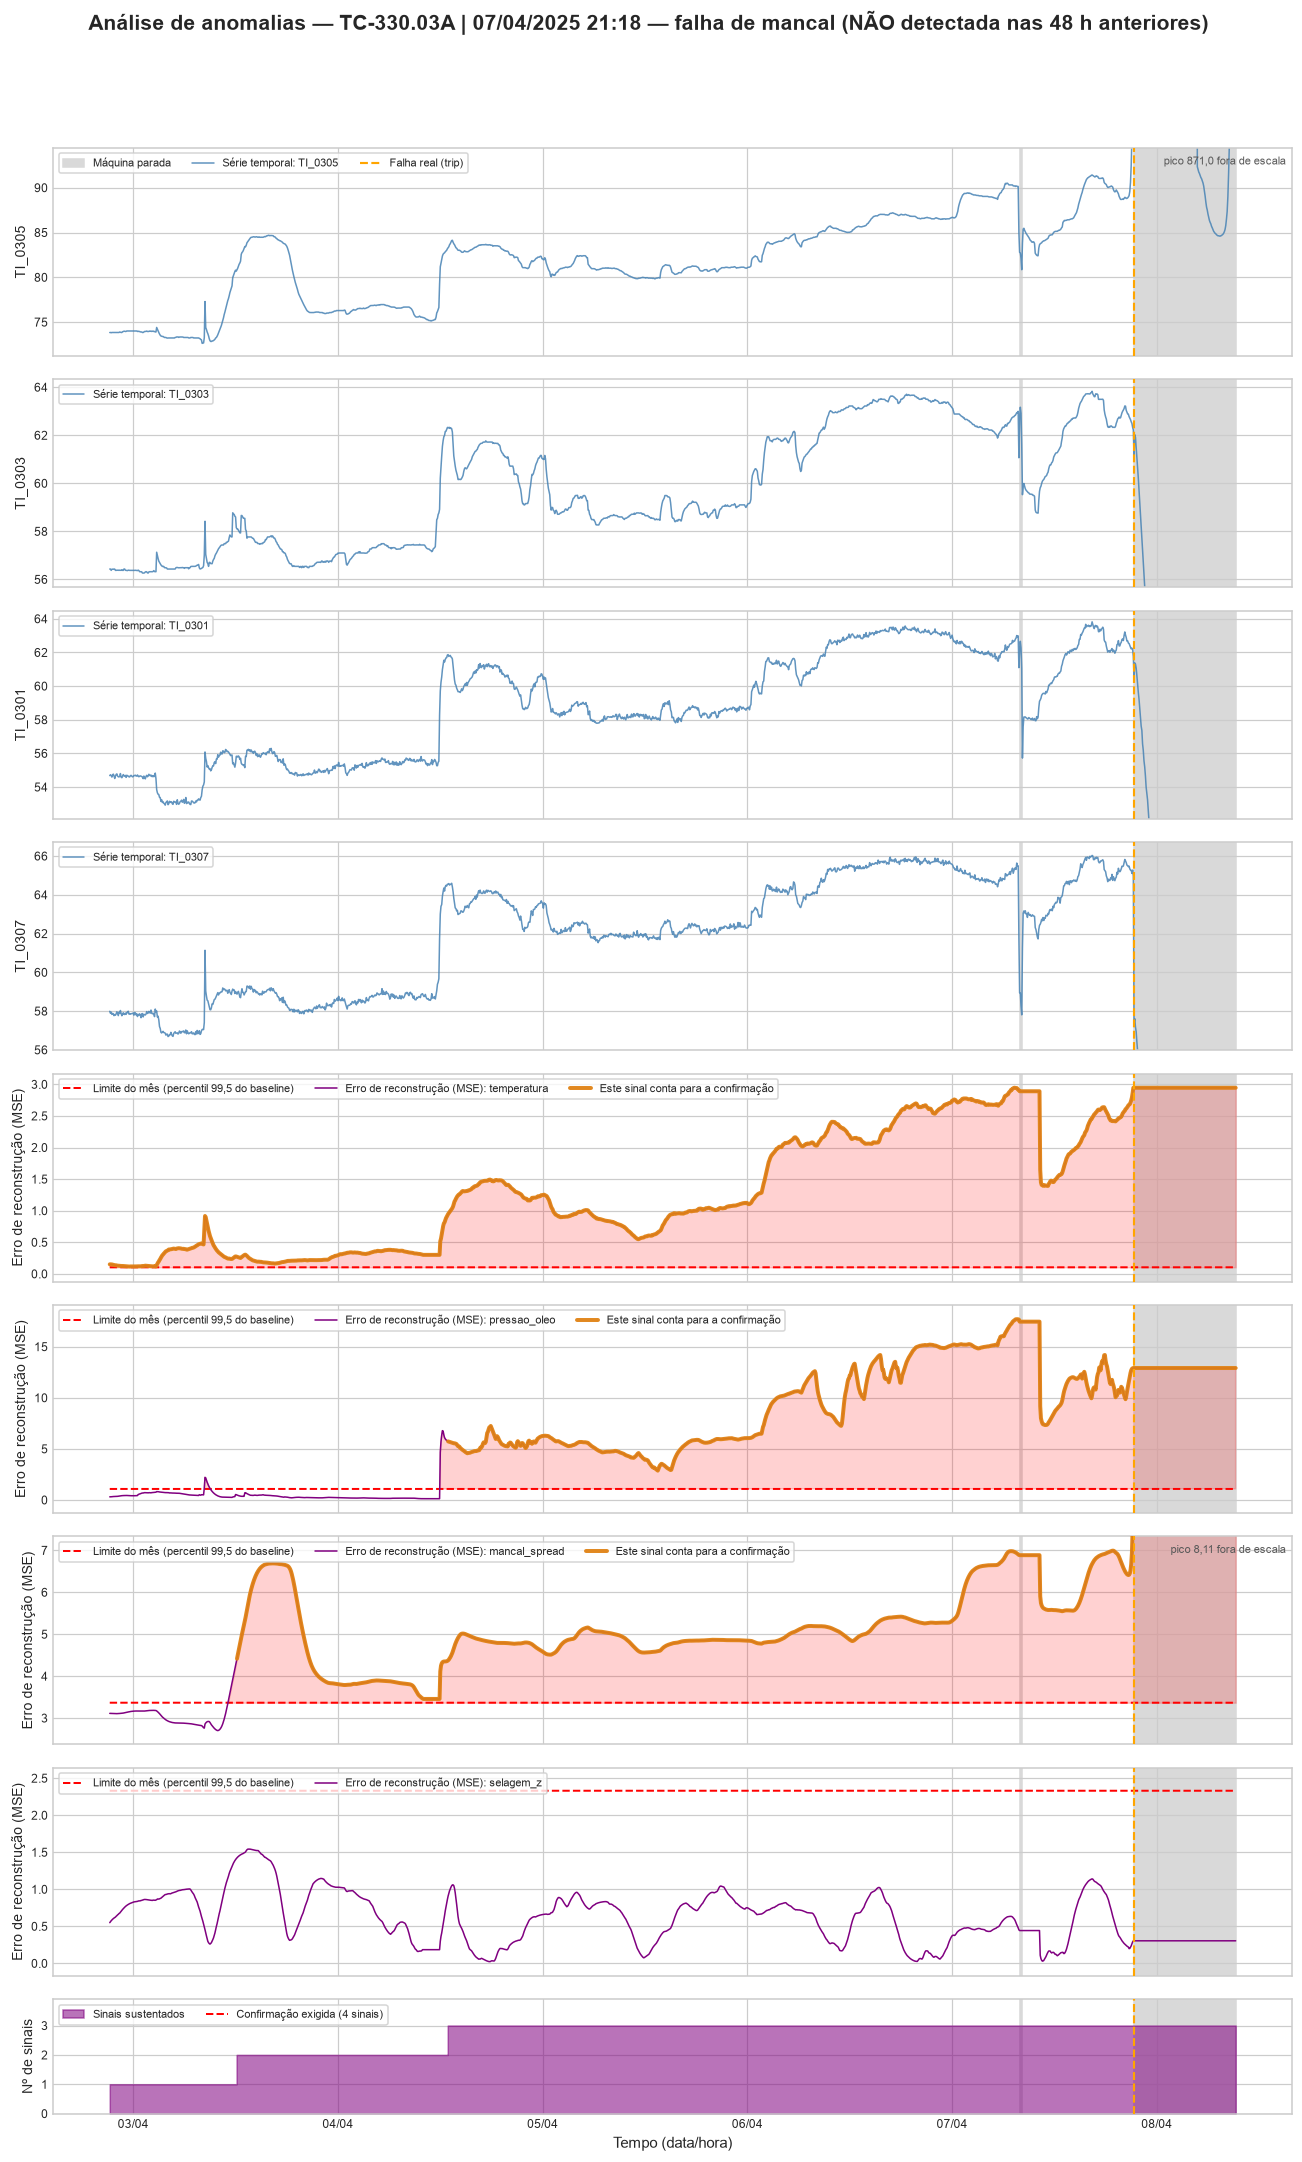

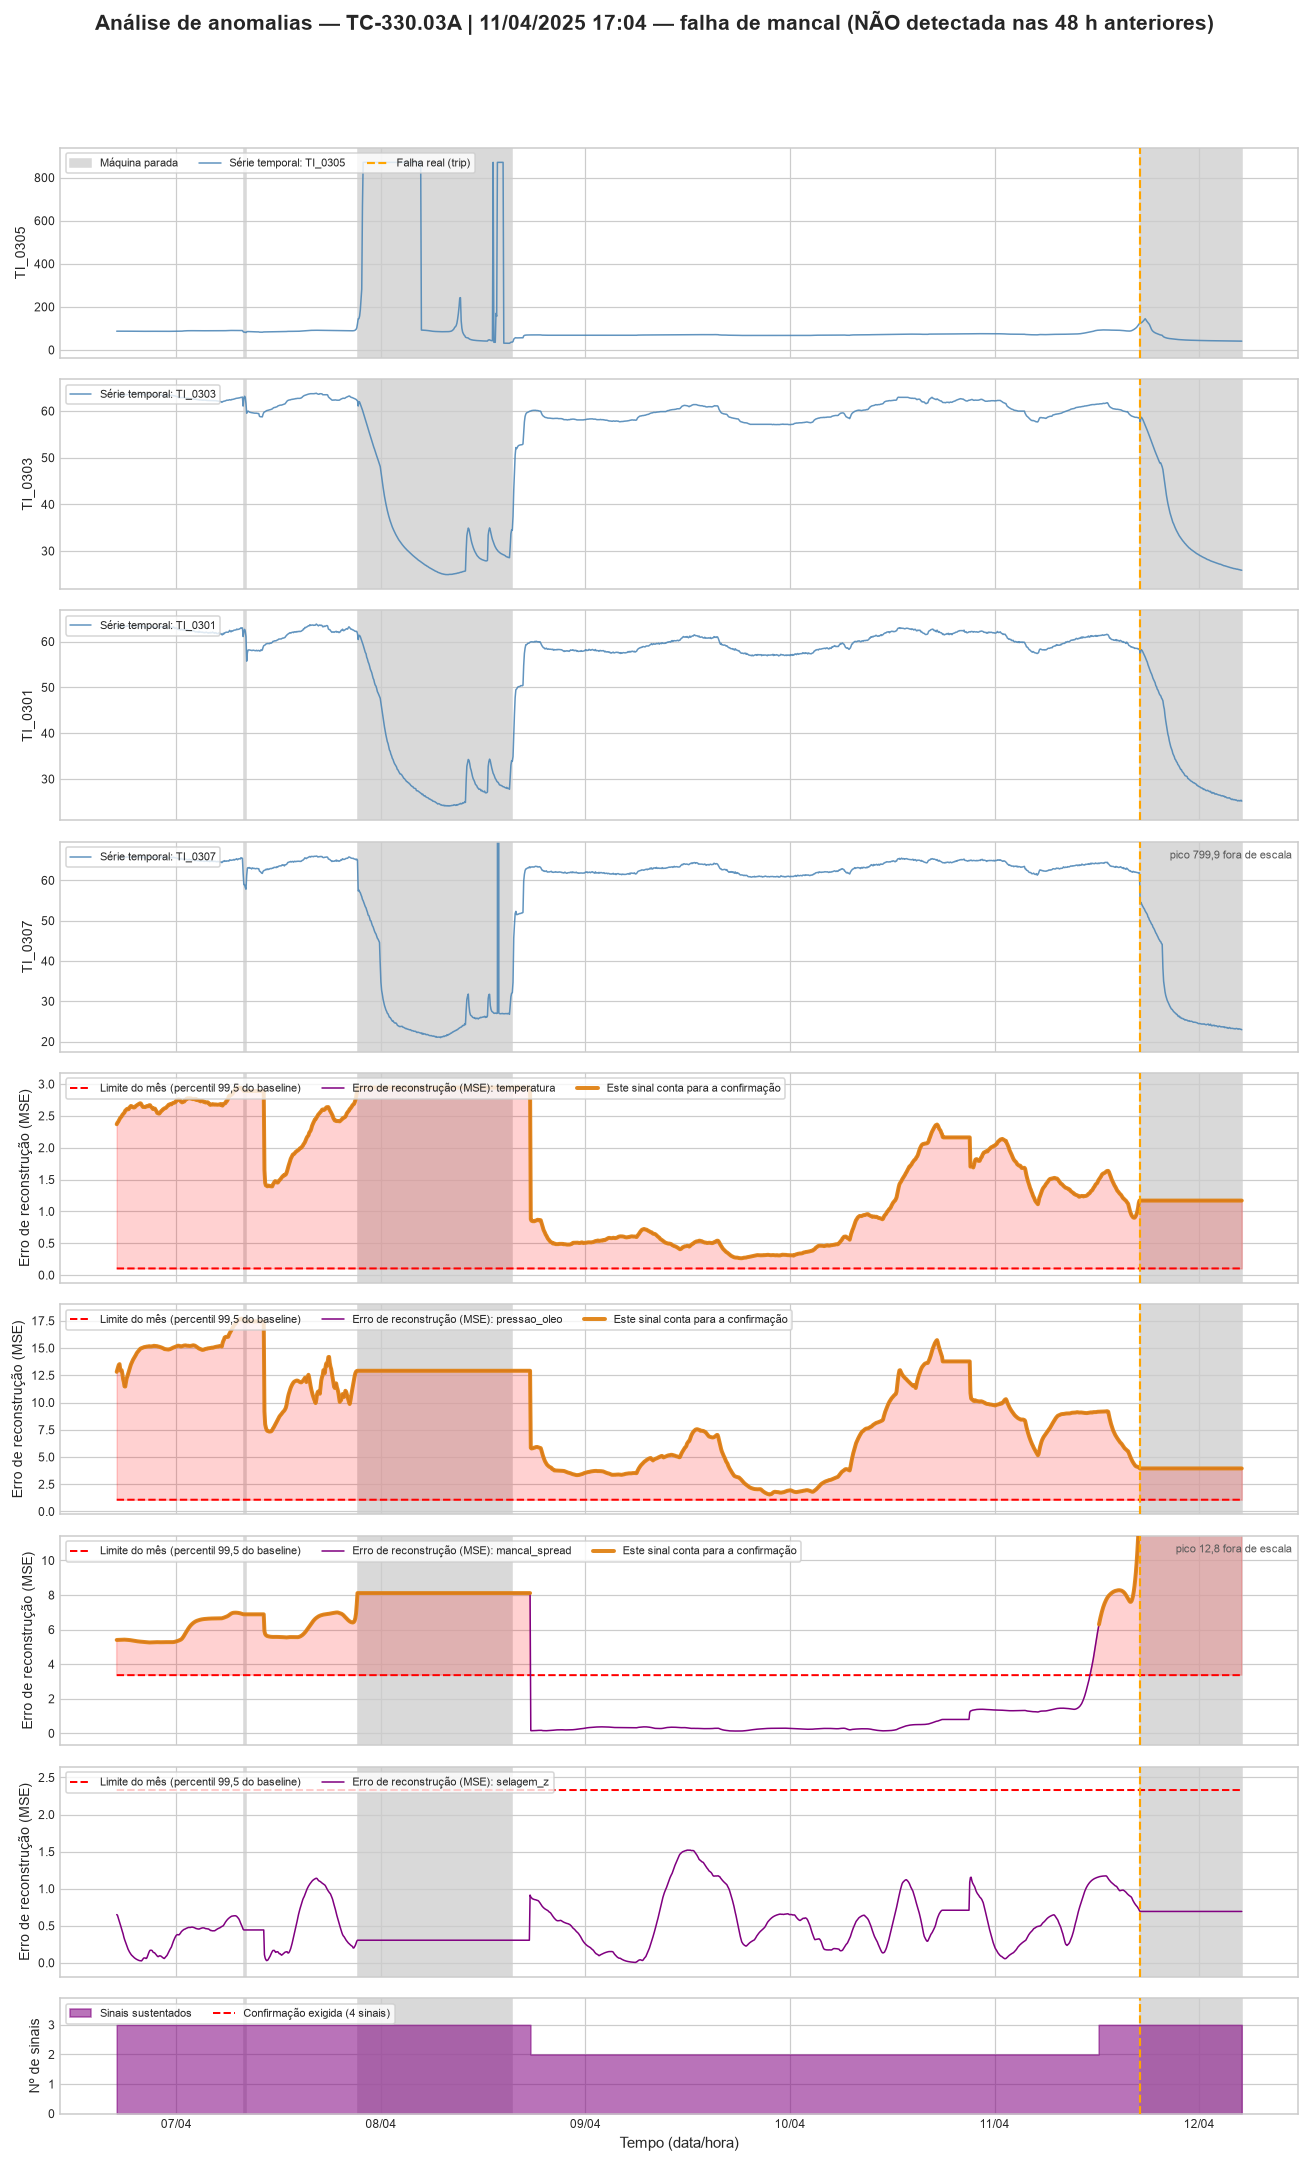

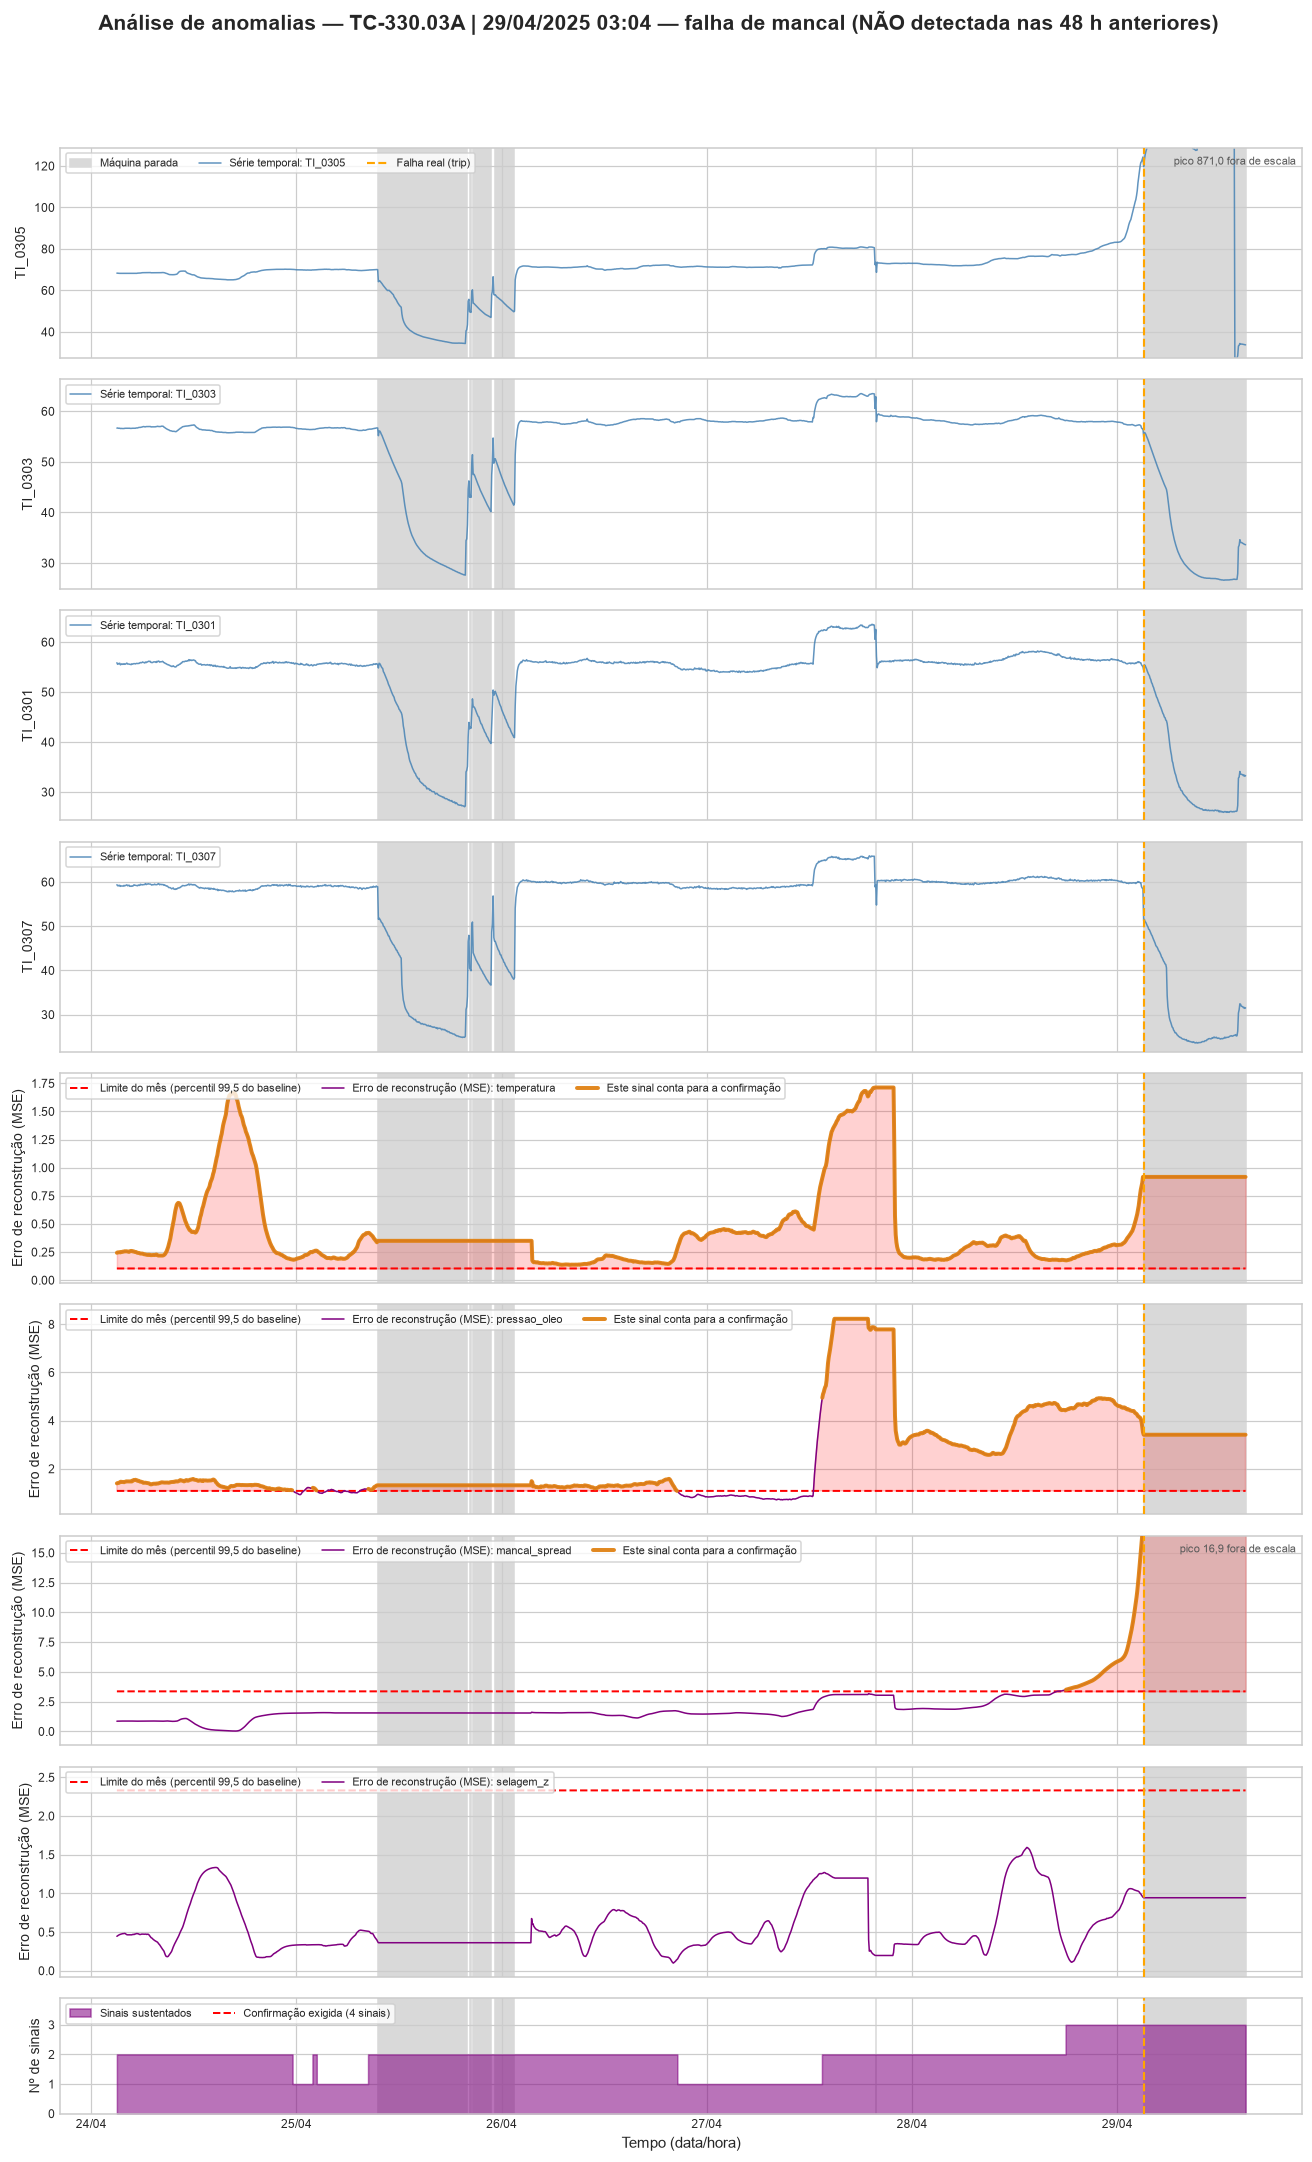

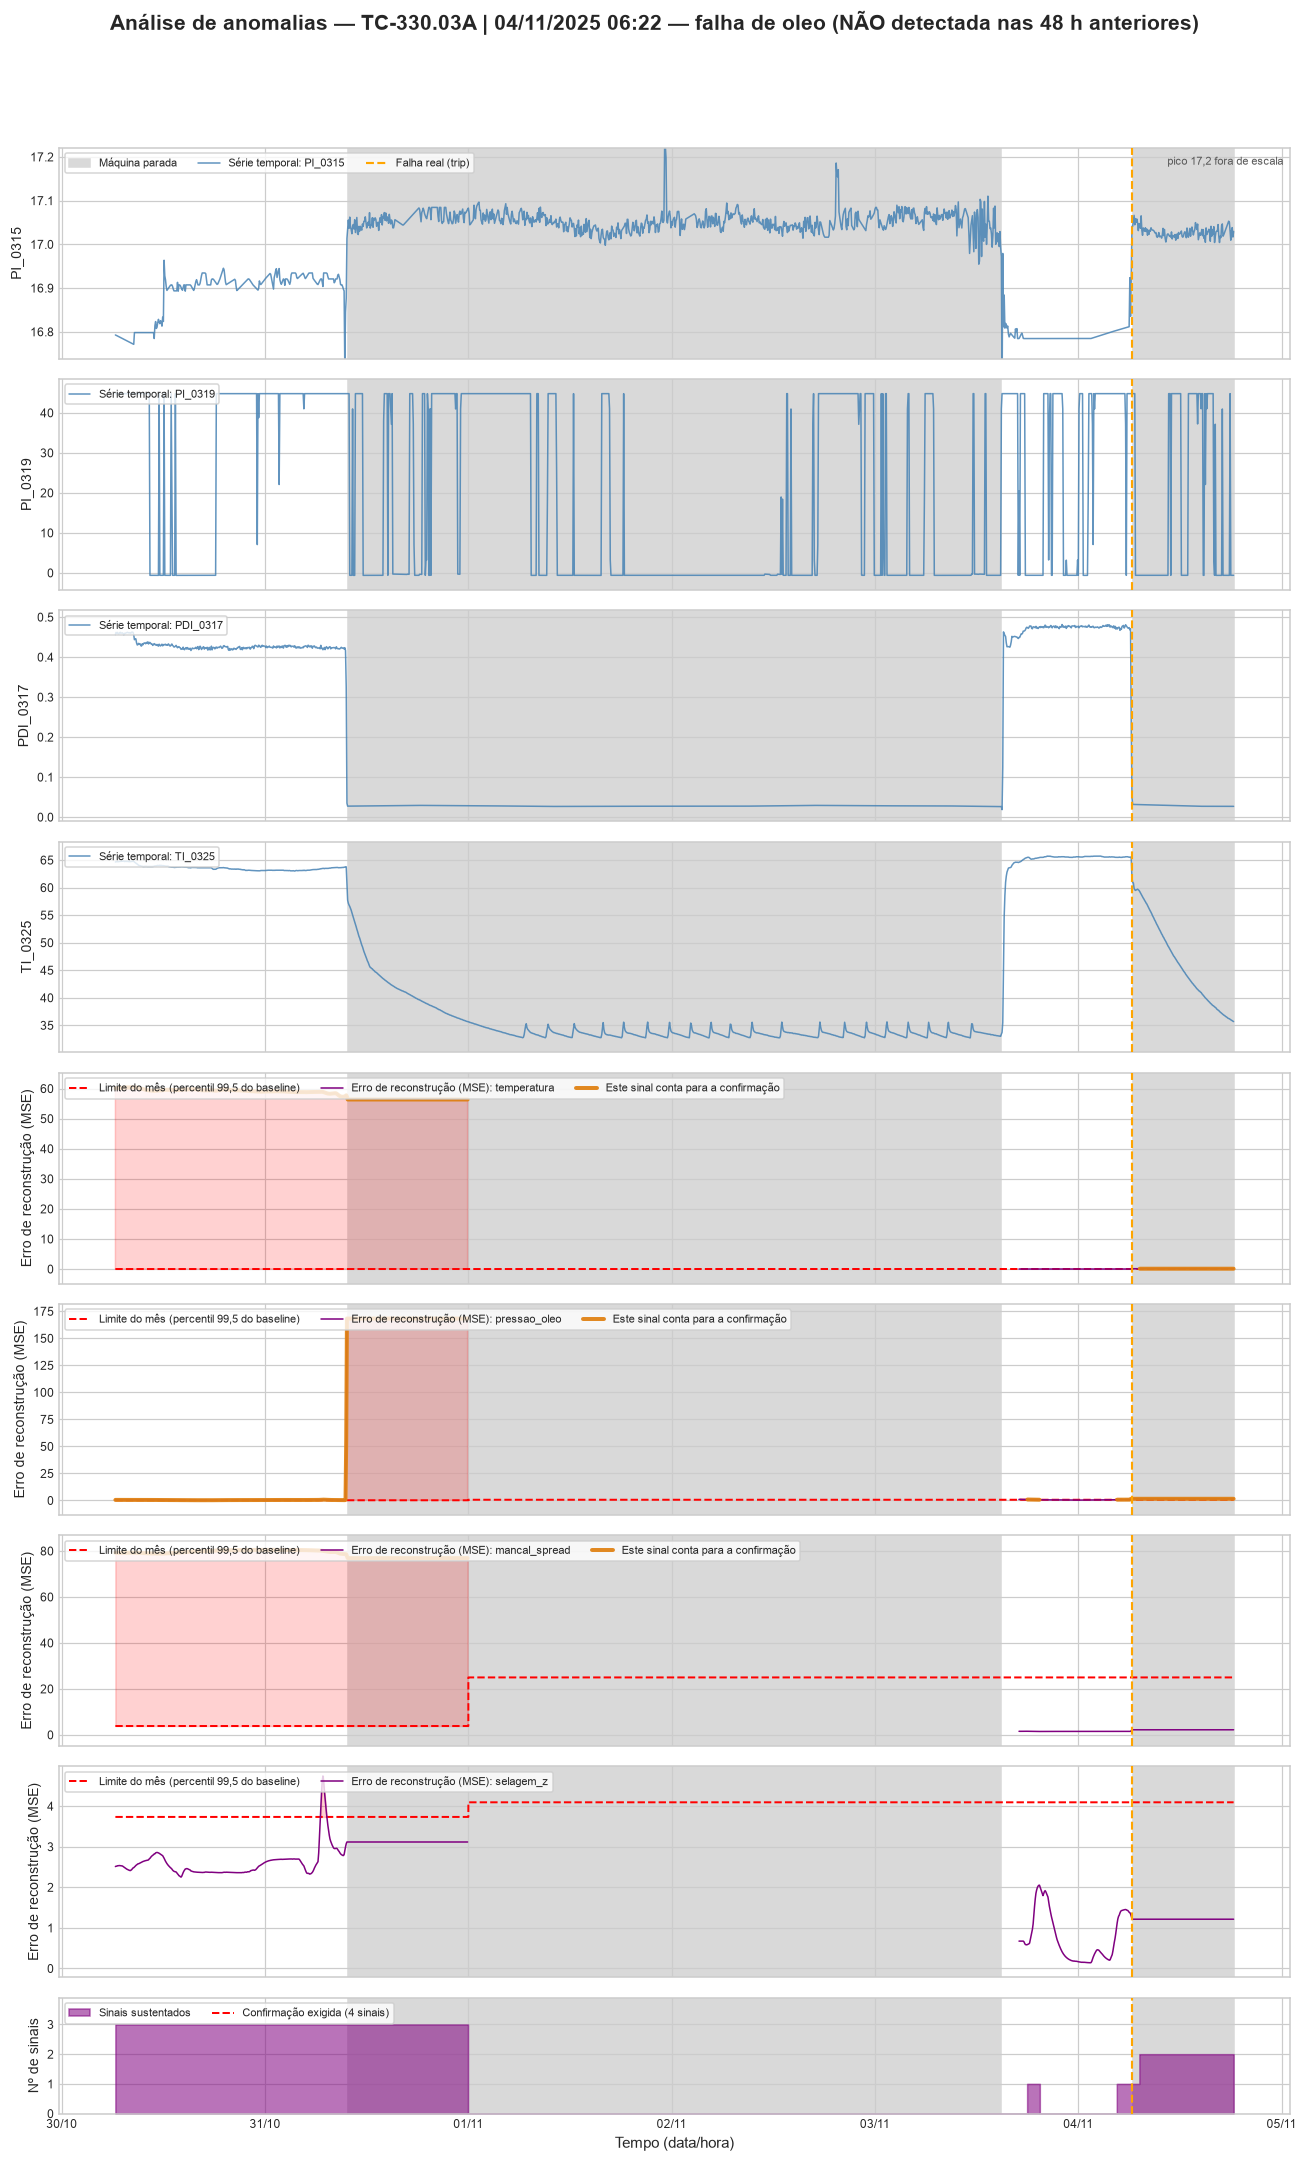

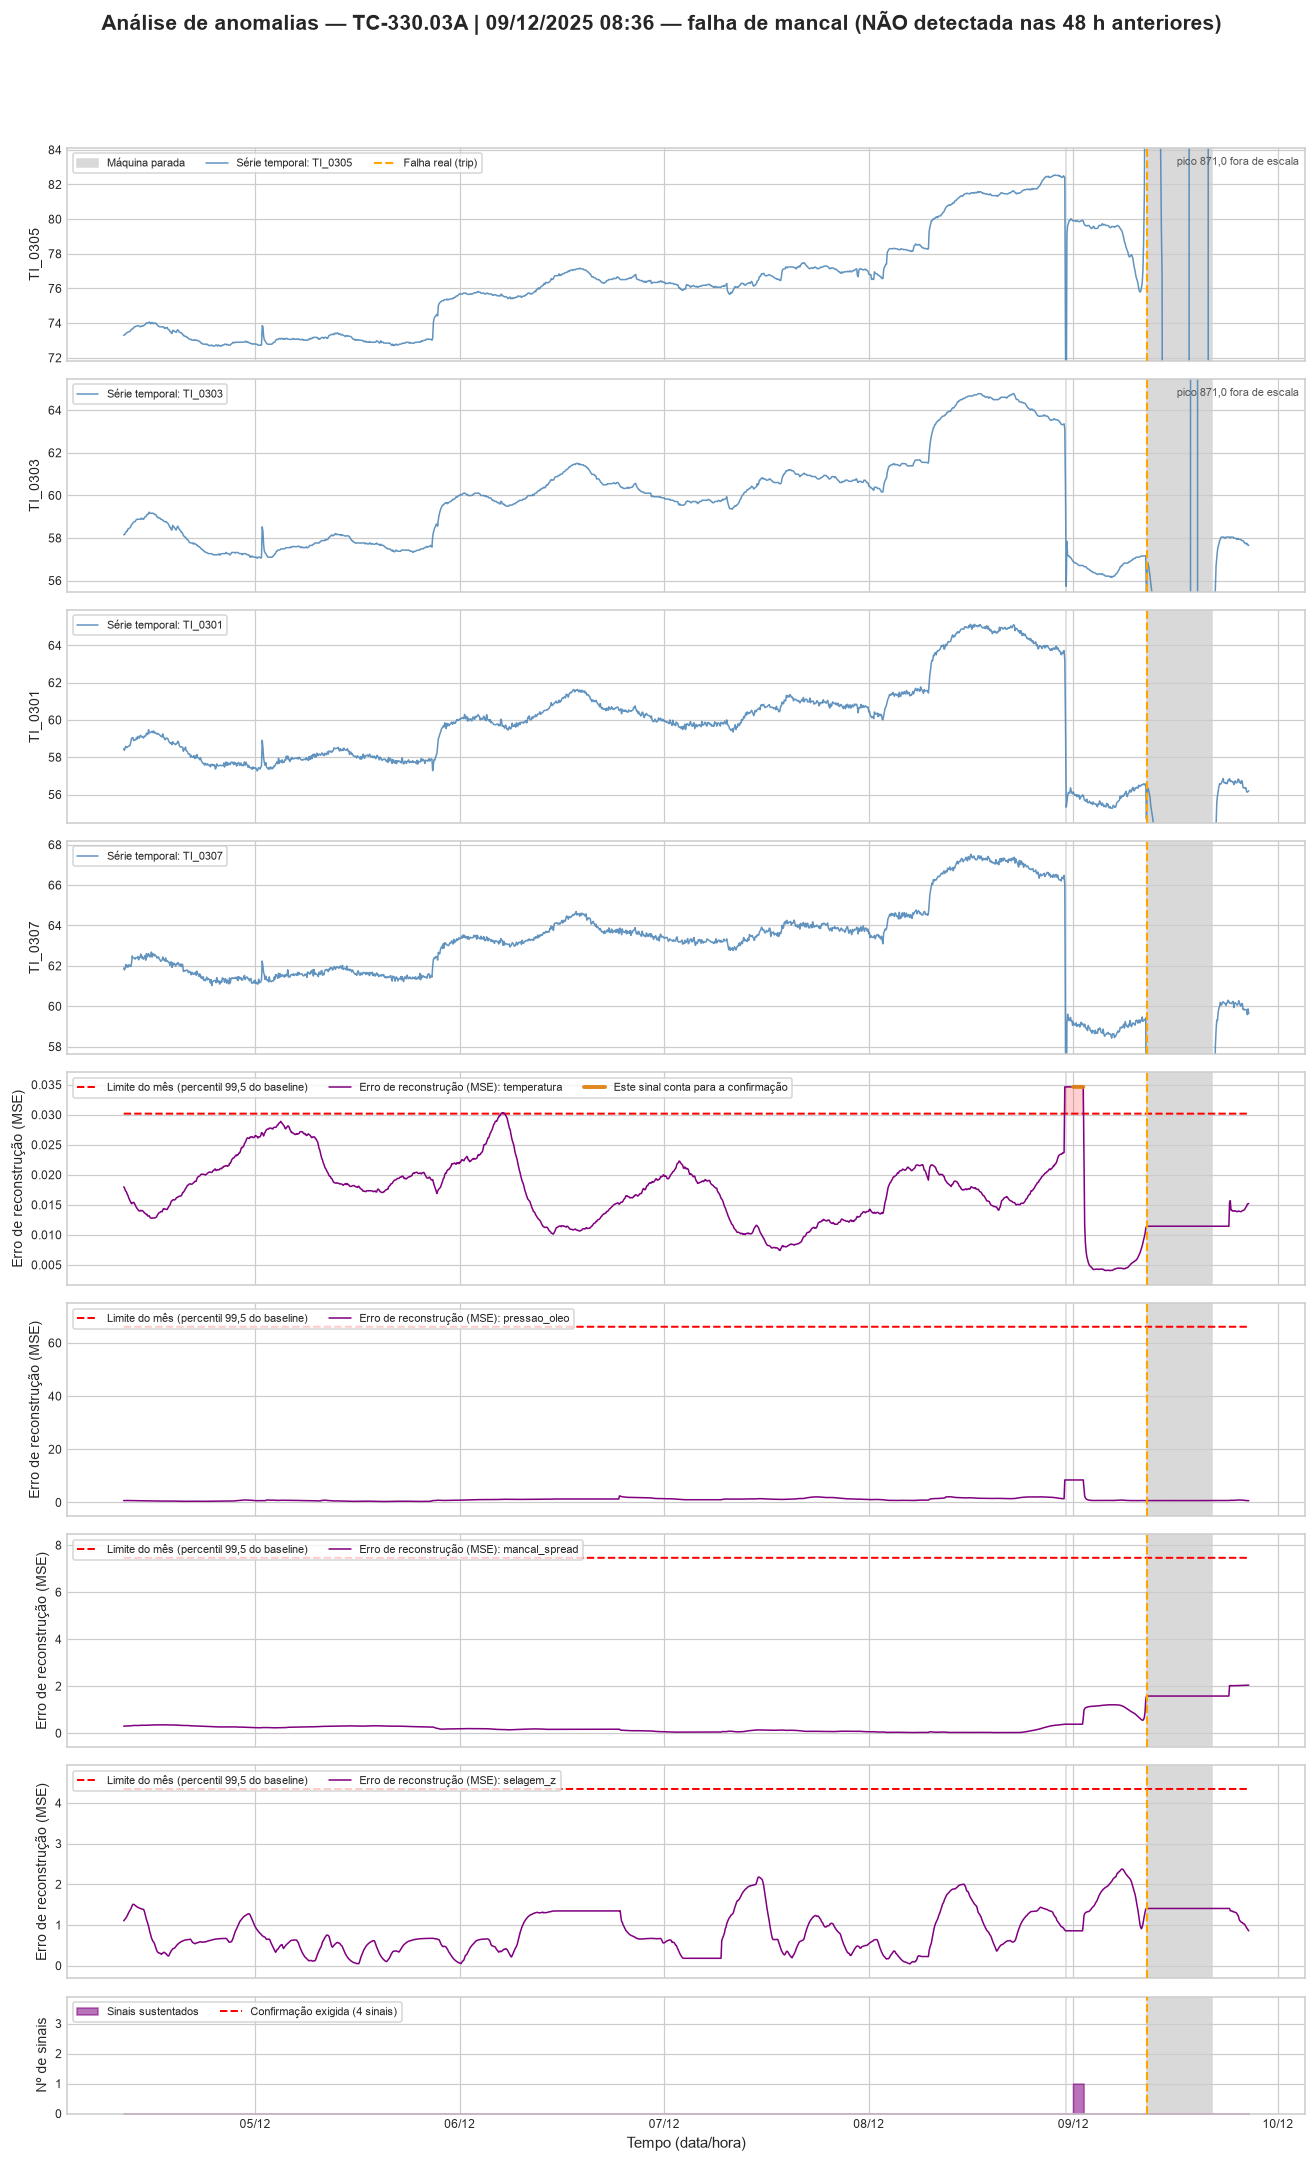

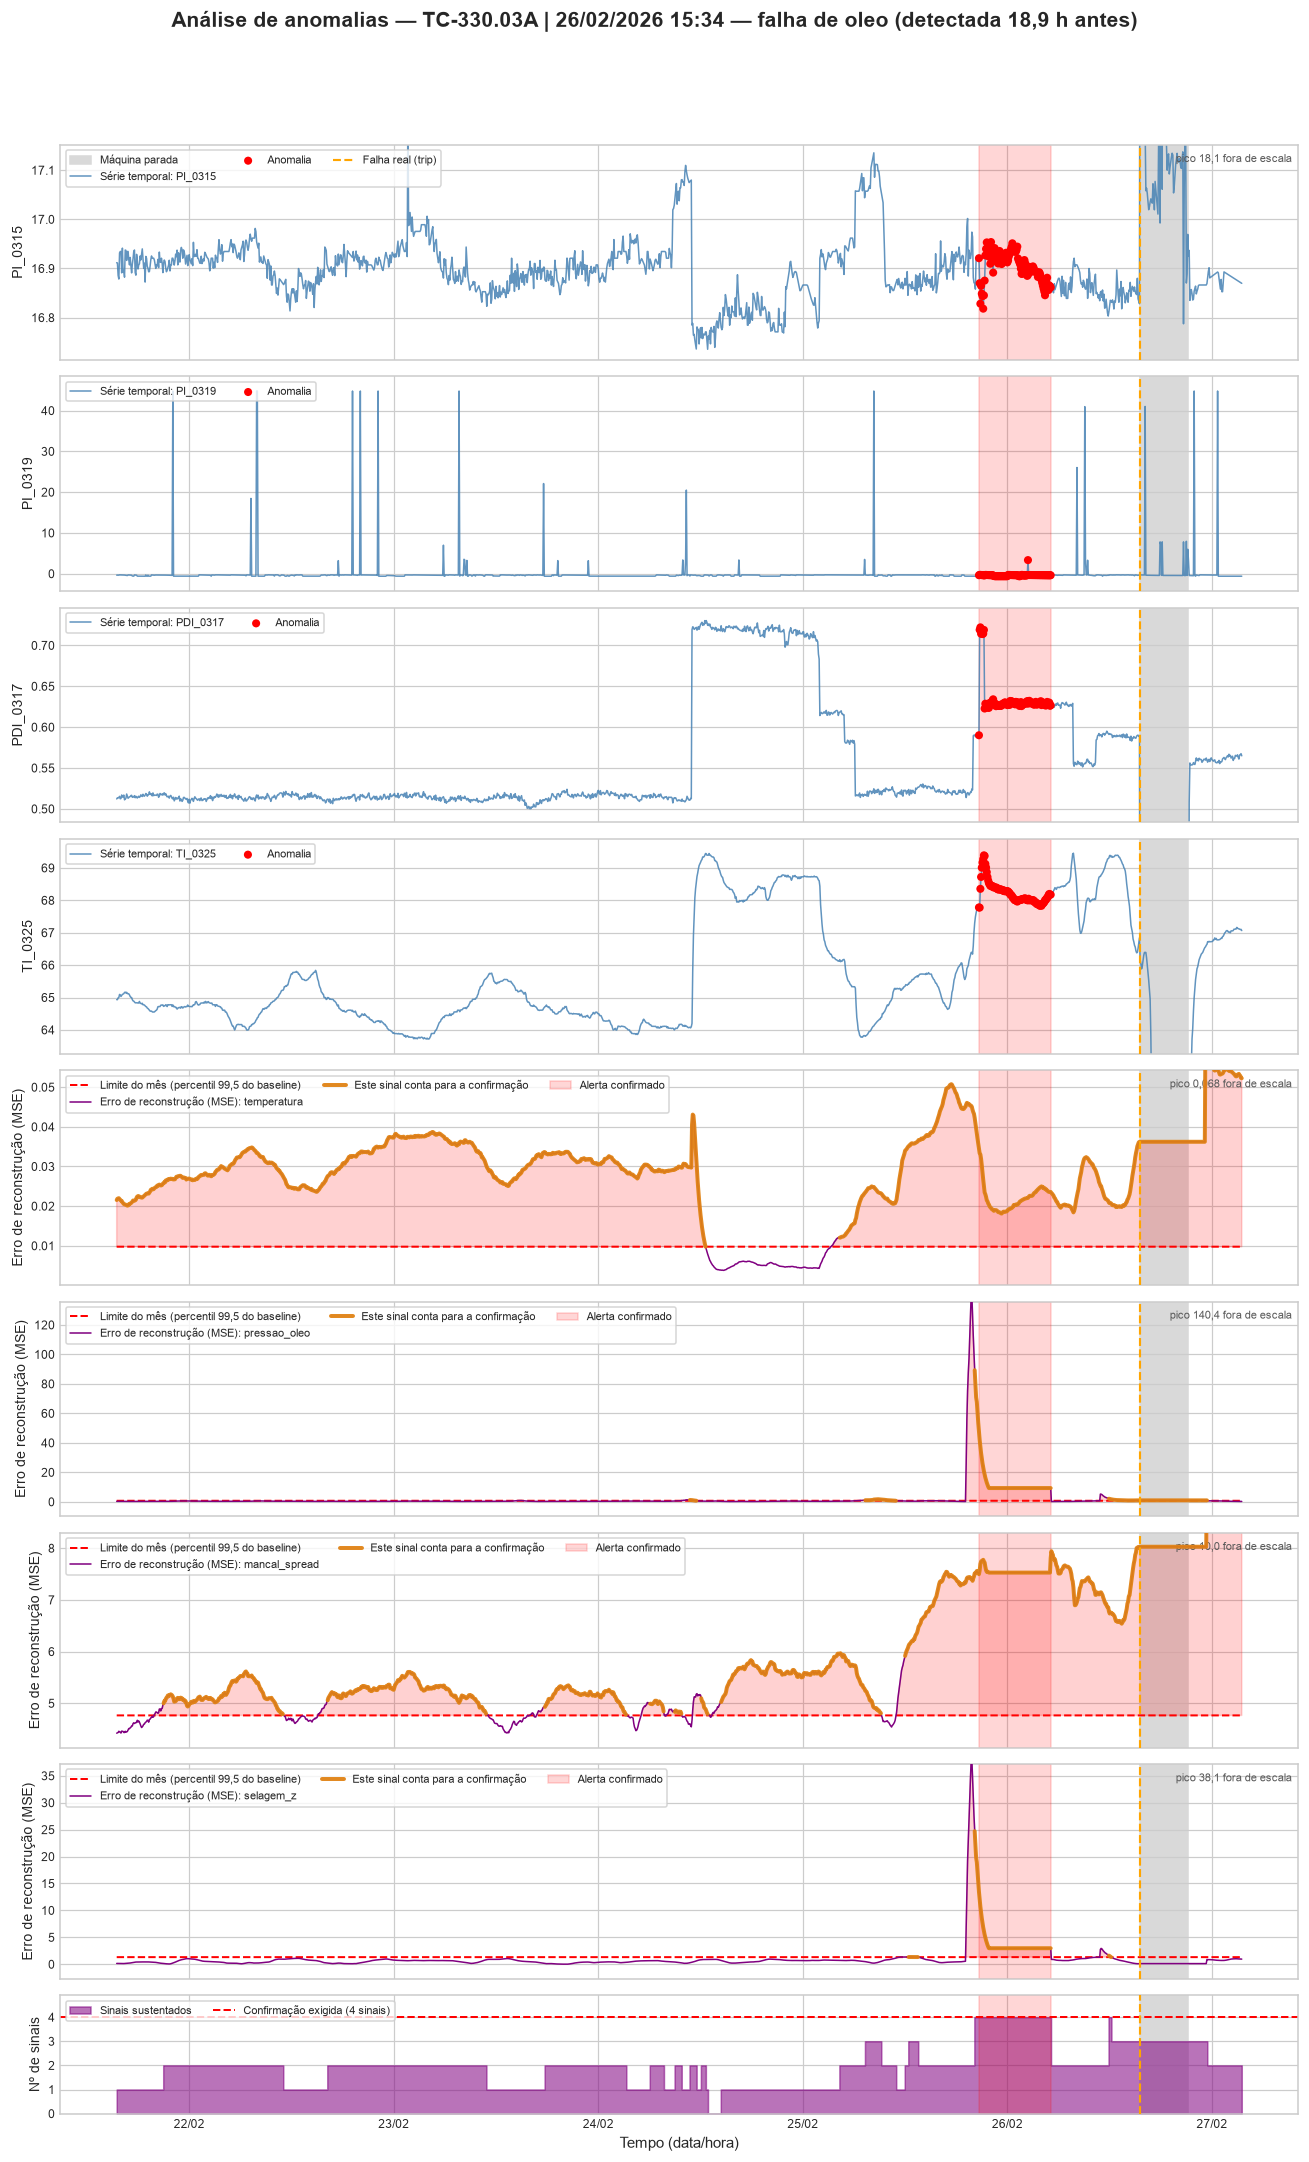

In [6]:
for evento in resultado.events:
    viz.plot_evento(resultado, evento)

### Lendo as seis figuras

* **17/03/2025 (mancal) — antecipada em 29,3 h.** As temperaturas dos mancais
  estão estáveis à vista desarmada; o que dispara é o score, quando a pressão
  também sai da faixa. A subida visível no sensor acontece depois do trip, nas
  tentativas de repartida.
* **26/02/2026 (óleo) — antecipada em 18,4 h.** É a figura mais clara do conjunto:
  temperatura e spread já vinham subindo desde 25/02, e o alerta fecha quando a
  pressão acompanha.
* **27/02/2025 (selagem) — não antecipada.** É o evento mais difícil da lista: a
  selagem se dilui na família de pressão. Um sinal dedicado (z de `PDIT_0305` /
  `PDI_0302`) é a pendência mais direta para resolver este caso.
* **07/04 e 11/04/2025 (mancal) — não antecipadas.** Aqui não há desculpa de dado:
  a coluna `operou_nas_48h` mostra que a máquina estava rodando praticamente a
  janela inteira antes de cada uma. São perdas de verdade. A de 07/04 é recuperada
  pelo ponto operacional da seção 7 (12,3 h de antecedência) — e vale olhar aquela
  figura com atenção: o spread do mancal e a temperatura vinham subindo desde
  05/04, mas o alerta fecha logo depois de uma parada curta, então parte da
  excursão pode ser transiente de repartida e não degradação.
* **04/11/2025 (óleo) — não antecipada**, e o único caso com janela precursora
  curta: a máquina havia religado ~15 h antes do trip, então só 15 das 48 h
  tinham dado. Esta figura ainda revelou um problema de método — seção 5.

*(Falha de partida — máquina que cai minutos depois de ligar, sem janela
precursora possível — é o caso dos trips de nov/2023, que estão fora do período
deste dataset. Nenhuma das seis falhas aqui é desse tipo.)*

## 3b. O erro de reconstrução, aberto por sensor

O modelo campeão é um **autoencoder**: ele aprende a reconstruir a leitura normal
dos sensores e o score é o **erro de reconstrução (MSE)** — o quanto a leitura de
agora escapa do que o modelo consegue reproduzir. É a mesma métrica que aparece
nos painéis roxos acima; aqui ela é aberta.

O score de uma família é a **média** do erro sobre os sensores dela. A média
esconde quem está errando: as figuras abaixo mostram, embaixo, a **participação de
cada sensor** no erro de cada instante (cada coluna soma 100%).

O modelo é ajustado no mesmo baseline que o walk-forward usaria para o mês da
falha — mesmos dias, mesma máscara de operação, mesma limpeza — então o erro
mostrado é o mesmo que entra no score.

17/03/2025 (mancal) — participação no erro antes da falha: TI_0305 61%, TC382_04_A 6%, TC382_03_A 6%


26/02/2026 (oleo) — participação no erro antes da falha: PDIT_0305 61%, PDI_0302 11%, PI_0308 7%


27/02/2025 (selagem) — participação no erro antes da falha: PDIT_0305 95%, PI_0319 1%, PDI_0301 1%


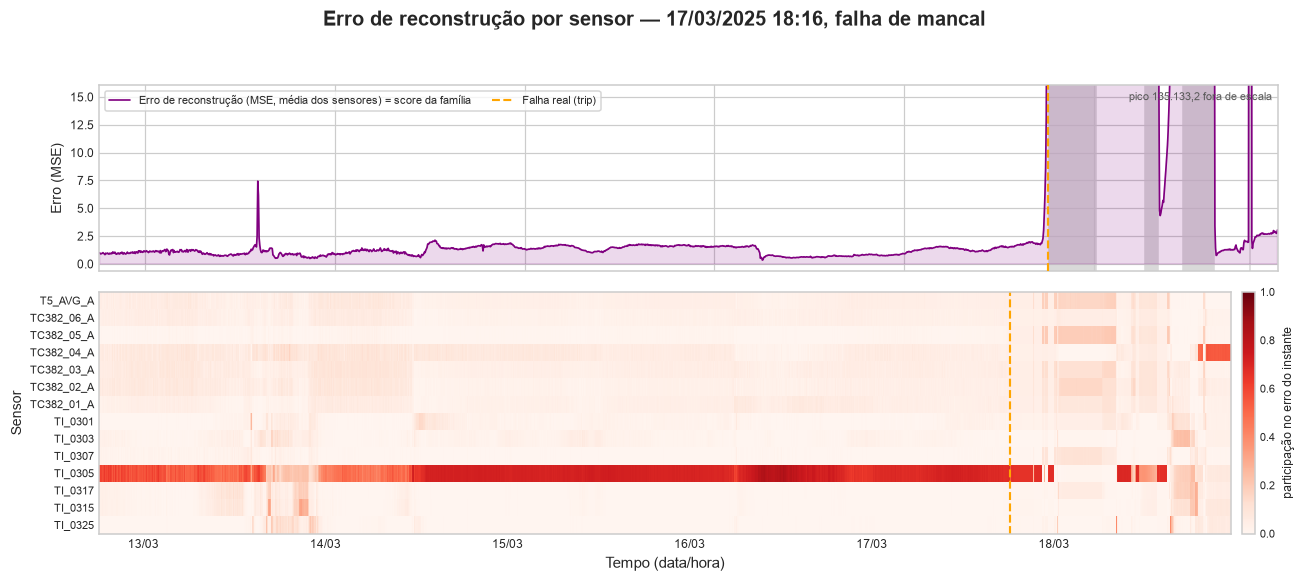

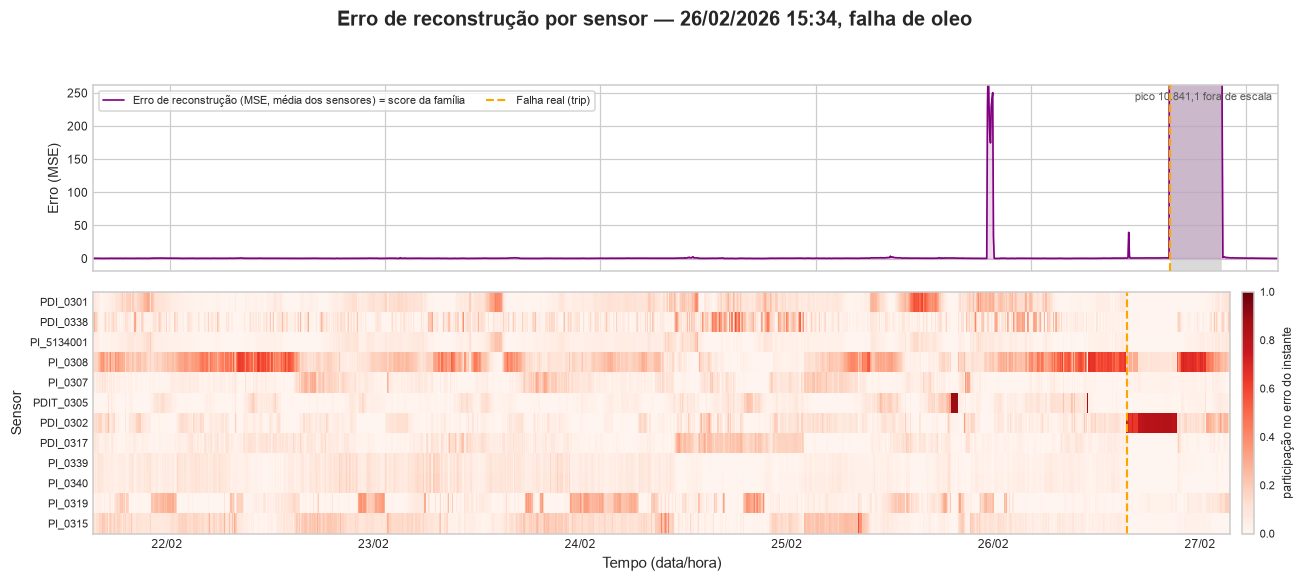

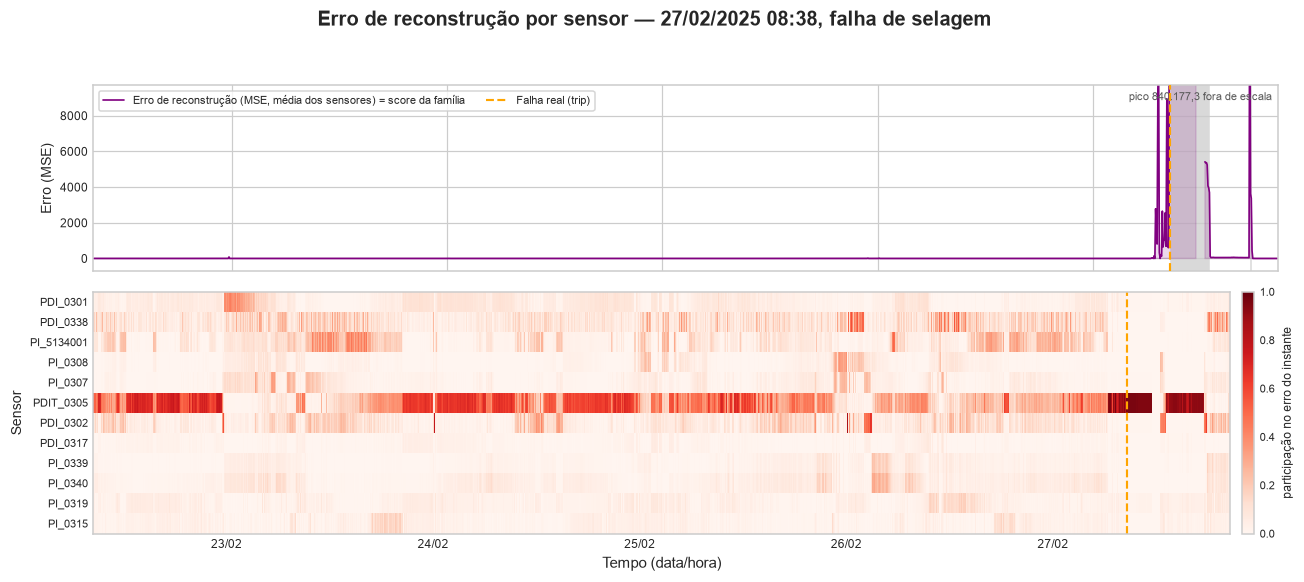

In [7]:
# três casos que contrastam: as duas falhas antecipadas e a que o detector não vê
# (índices na lista de 8 eventos: 1 = 17/03 mancal, 7 = 26/02/26 óleo, 0 = 27/02 selagem)
for evento in [resultado.events[1], resultado.events[7], resultado.events[0]]:
    erros = replay.erro_por_sensor(evento, **{k: CONSERVADOR[k] for k in
                                              ("model", "grid", "baseline_hours",
                                               "exclude_days", "exclude_alarm_h")})
    viz.plot_erro_por_sensor(erros, evento, resultado.operability)
    # o ranking é medido só ANTES do trip: depois dele todos os sensores explodem
    antes = erros.loc[:evento["inicio"]].mean()
    share = (antes / antes.sum()).nlargest(3)
    print(f"{evento['inicio']:%d/%m/%Y} ({evento['mecanismo']}) — participação no erro "
          f"antes da falha: " + ", ".join(f"{s.replace('954005_624_', '')} {v:.0%}"
                                          for s, v in share.items()))

### O que isso mostra

Medindo a participação **antes** do trip (depois dele todos os sensores explodem e
o ranking perde sentido), os três casos dizem a mesma coisa:

| Falha | Sensor que domina o erro | Participação |
|---|---|---|
| 17/03/2025 · mancal | `TI_0305` — o mancal que disparou o alarme | **46%** |
| 26/02/2026 · óleo | `PDIT_0305` | **55%** |
| 27/02/2025 · selagem | `PDIT_0305` — o diferencial de selagem | **53%** |

**Em todos os três, o sensor que domina o erro é o do mecanismo que falhou.** O
autoencoder não está só dizendo "algo mudou": ele aponta para onde olhar. Isso é o
que transformaria o alerta em aviso acionável.

E aqui está o achado incômodo: **na falha de selagem de 27/02/2025 o `PDIT_0305`
respondia por 53% do erro — e mesmo assim não houve alerta.** A informação estava
lá; o que a perdeu foi a agregação. O score da família de pressão é a **média**
sobre 12 sensores, então um sensor gritando vira um sussurro depois de dividido
por 12, e a confirmação por 3 sinais nunca fecha.

É a justificativa mais direta para a pendência do **sinal dedicado de selagem**
(z de `PDIT_0305`/`PDI_0302`, no mesmo formato do spread do mancal): não é preciso
sensor novo nem dado novo — é preciso parar de diluir o que já existe.

## 4. O modelo contra a planilha de alarmes

A mesma série, agora com os alarmes de nível registrados pela instrumentação
(traços azuis na base). Serve para responder "o modelo está só repetindo o alarme
que já existe?" — e a resposta importa: o alarme de nível dispara **no** trip (ou
depois, com a máquina já parada), enquanto a anomalia aparece antes.

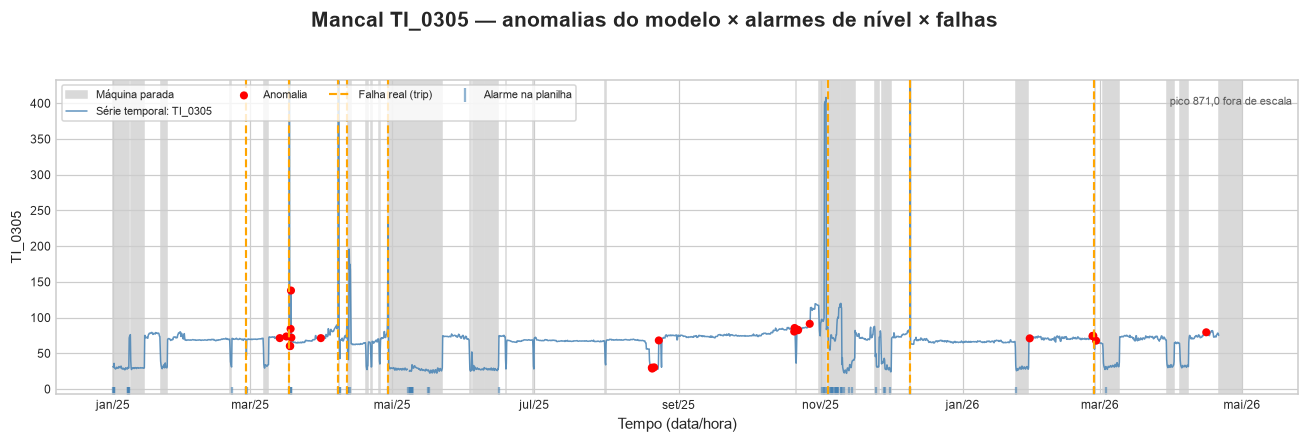

In [8]:
alarmes = load_alarms()
ativacoes_trip = alarmes[alarmes["ativado"] & alarmes["nivel_trip"]].index

viz.plot_sensor(resultado, "954005_624_TI_0305", alarmes=ativacoes_trip,
                titulo="Mancal TI_0305 — anomalias do modelo × alarmes de nível × falhas");

## 5. Achado: o alerta sobrevive à máquina parada

Na figura de 04/11/2025 há pontos vermelhos **dentro da faixa cinza** — ou seja,
alerta com a máquina desligada. Isso não deveria acontecer: o score é mascarado
fora de operação. A causa é a ordem das operações no AutoML: o score é mascarado
**antes** da suavização, e a média exponencial (EWMA) carrega o último valor
válido para frente — então o score continua definido durante a parada, e o alerta
que estava de pé permanece de pé.

O replay tem um modo de diagnóstico (`mask_stops=True`) que anula o alerta fora
de operação, para medir o tamanho do efeito sem mexer no AutoML:

In [9]:
comparacao = {}
for nome, cfg in [("conservador", CONSERVADOR), ("operacional", OPERACIONAL)]:
    for mascara in (False, True):
        chave = f"{nome}{' + máscara' if mascara else ''}"
        comparacao[chave] = replay.run(**cfg, mask_stops=mascara).metrics
pd.DataFrame(comparacao).loc[["eventos_detectados", "lead_medio_h", "fp_episodios",
                              "fp_por_mes", "episodios_totais"]]

[scores] cache replay_parts_4sinais_ae_30s_300h_0_1.0_809a6e47.pkl


[replay] ae|30s|b300h|excl0d|alm1.0h|ewma30min|q99.5|sust1h|conf4|min30min -> 2/8 eventos | lead 24.4 h | FP 0.77/mês
[scores] cache replay_parts_4sinais_ae_30s_300h_0_1.0_809a6e47.pkl


[replay] ae|30s|b300h|excl0d|alm1.0h|ewma30min|q99.5|sust1h|conf4|min30min +mascara paradas -> 2/8 eventos | lead 24.4 h | FP 0.77/mês
[scores] cache replay_parts_4sinais_pca_2min_acum_0_1.0_1e2d53f7.pkl


[replay] pca|2min|bacum|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min -> 5/8 eventos | lead 17.9 h | FP 0.77/mês
[scores] cache replay_parts_4sinais_pca_2min_acum_0_1.0_1e2d53f7.pkl


[replay] pca|2min|bacum|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min +mascara paradas -> 5/8 eventos | lead 17.9 h | FP 1.71/mês


,conservador,conservador + máscara,operacional,operacional + máscara
eventos_detectados,2,2,5,5
lead_medio_h,24.4,24.4,17.9,17.9
fp_episodios,9,9,9,20
fp_por_mes,0.77,0.77,0.77,1.71
episodios_totais,14,13,17,30


**O efeito é pequeno e não é uniformemente favorável.** No ponto conservador o
falso positivo cai de 0,77 para 0,60 por mês (9 → 7 episódios) sem perder
detecção. No ponto operacional ele *sobe* de 1,20 para 1,29: mascarar a parada
**fragmenta** episódios que a atravessavam (o total sai de 28 para 39), e cada
pedaço passa a contar como um episódio novo.

A correção completa seria mascarar **e** unir episódios separados apenas por uma
parada. Como isso altera a definição de episódio e obrigaria a repetir a busca,
fica registrado como decisão a tomar — não foi aplicado por conta própria.
Detecção não muda em nenhum dos dois casos, então nada do que está reportado até
aqui perde validade.

## 6. O que o número de falso positivo não conta: a duração

A métrica conta **episódios**, não tempo. Cada ponto abaixo é um alerta, na
altura do tempo que ele ficou de pé:

,inicio,duracao_h,tipo
0,2025-03-13 18:32:00,0.03,falso positivo
1,2025-03-16 12:28:00,0.67,detecção
2,2025-03-18 03:58:30,13.27,antes de parada (não contado)
3,2025-03-31 09:10:00,1.35,antes de parada (não contado)
4,2025-08-20 13:52:00,2.76,falso positivo
5,2025-08-21 14:19:30,0.66,falso positivo
6,2025-08-23 14:03:00,1.60,falso positivo
7,2025-10-20 17:41:30,3.61,antes de parada (não contado)
8,2025-10-22 07:45:30,0.53,falso positivo
9,2025-10-27 10:41:30,0.77,falso positivo


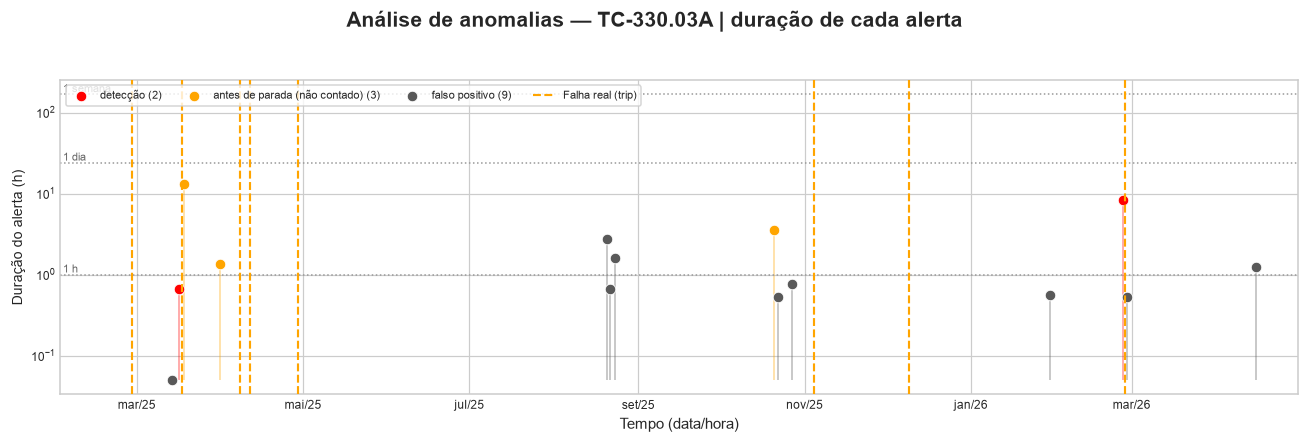

In [10]:
viz.plot_episodios(resultado)
resultado.episodes_table()

Duas leituras incômodas, e ambas importam mais que a média:

1. **A detecção de 17/03/2025 durou 9 minutos.** Antecedência de 29,3 h no papel,
   mas um alerta que aparece e desaparece nesse intervalo passa batido em um
   plantão. A de 26/02/2026 durou 2,2 h, o que já é operável.
2. **Dois falsos positivos duraram cerca de uma semana** (mar/2026 e abr/2026,
   ~150–170 h). Contam como *um* episódio cada na métrica, mas um alarme travado
   por uma semana é o tipo de coisa que faz a operação desligar o sistema.

Ou seja: o teto de "1 falso positivo por mês" é necessário mas não suficiente.
Vale acrescentar à política um critério de duração — por exemplo, exigir que o
alerta se sustente por um mínimo para ser emitido (o que ajudaria o caso 1) e que
se re-arme depois de um tempo em vez de ficar de pé indefinidamente (caso 2).

## 7. O que custa detectar uma falha a mais

A configuração acima respeita o teto de 1 falso positivo por mês. Afrouxando o
limiar e alongando a persistência (`EWMA 1 h`, `q99,9`, `sustentado 4 h`), a
busca encontra um ponto que **antecipa uma falha a mais**, ao custo de mais
alarme falso. A escolha entre os dois é de operação, não técnica: é decidir
quantos alarmes falsos por mês a equipe aceita receber.

[scores] cache replay_parts_4sinais_pca_2min_acum_0_1.0_1e2d53f7.pkl


[replay] pca|2min|bacum|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min -> 5/8 eventos | lead 17.9 h | FP 0.77/mês


falhas que só o ponto operacional antecipa: ['27/02/2025 (selagem, 33.2 h)', '07/04/2025 (mancal, 19.5 h)', '11/04/2025 (mancal, 3.8 h)', '29/04/2025 (mancal, 2.5 h)']


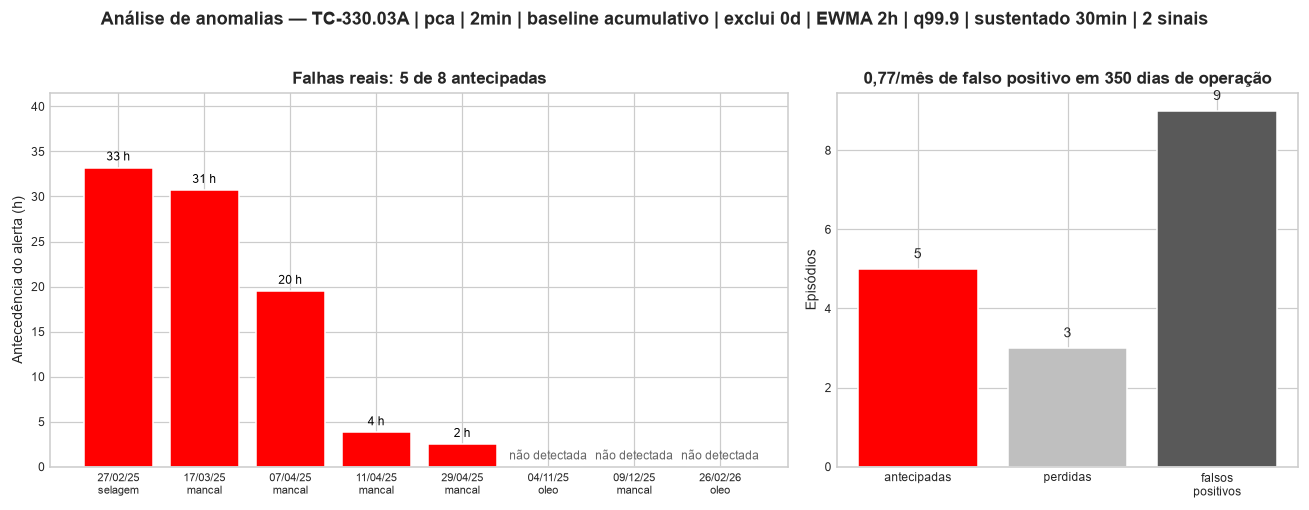

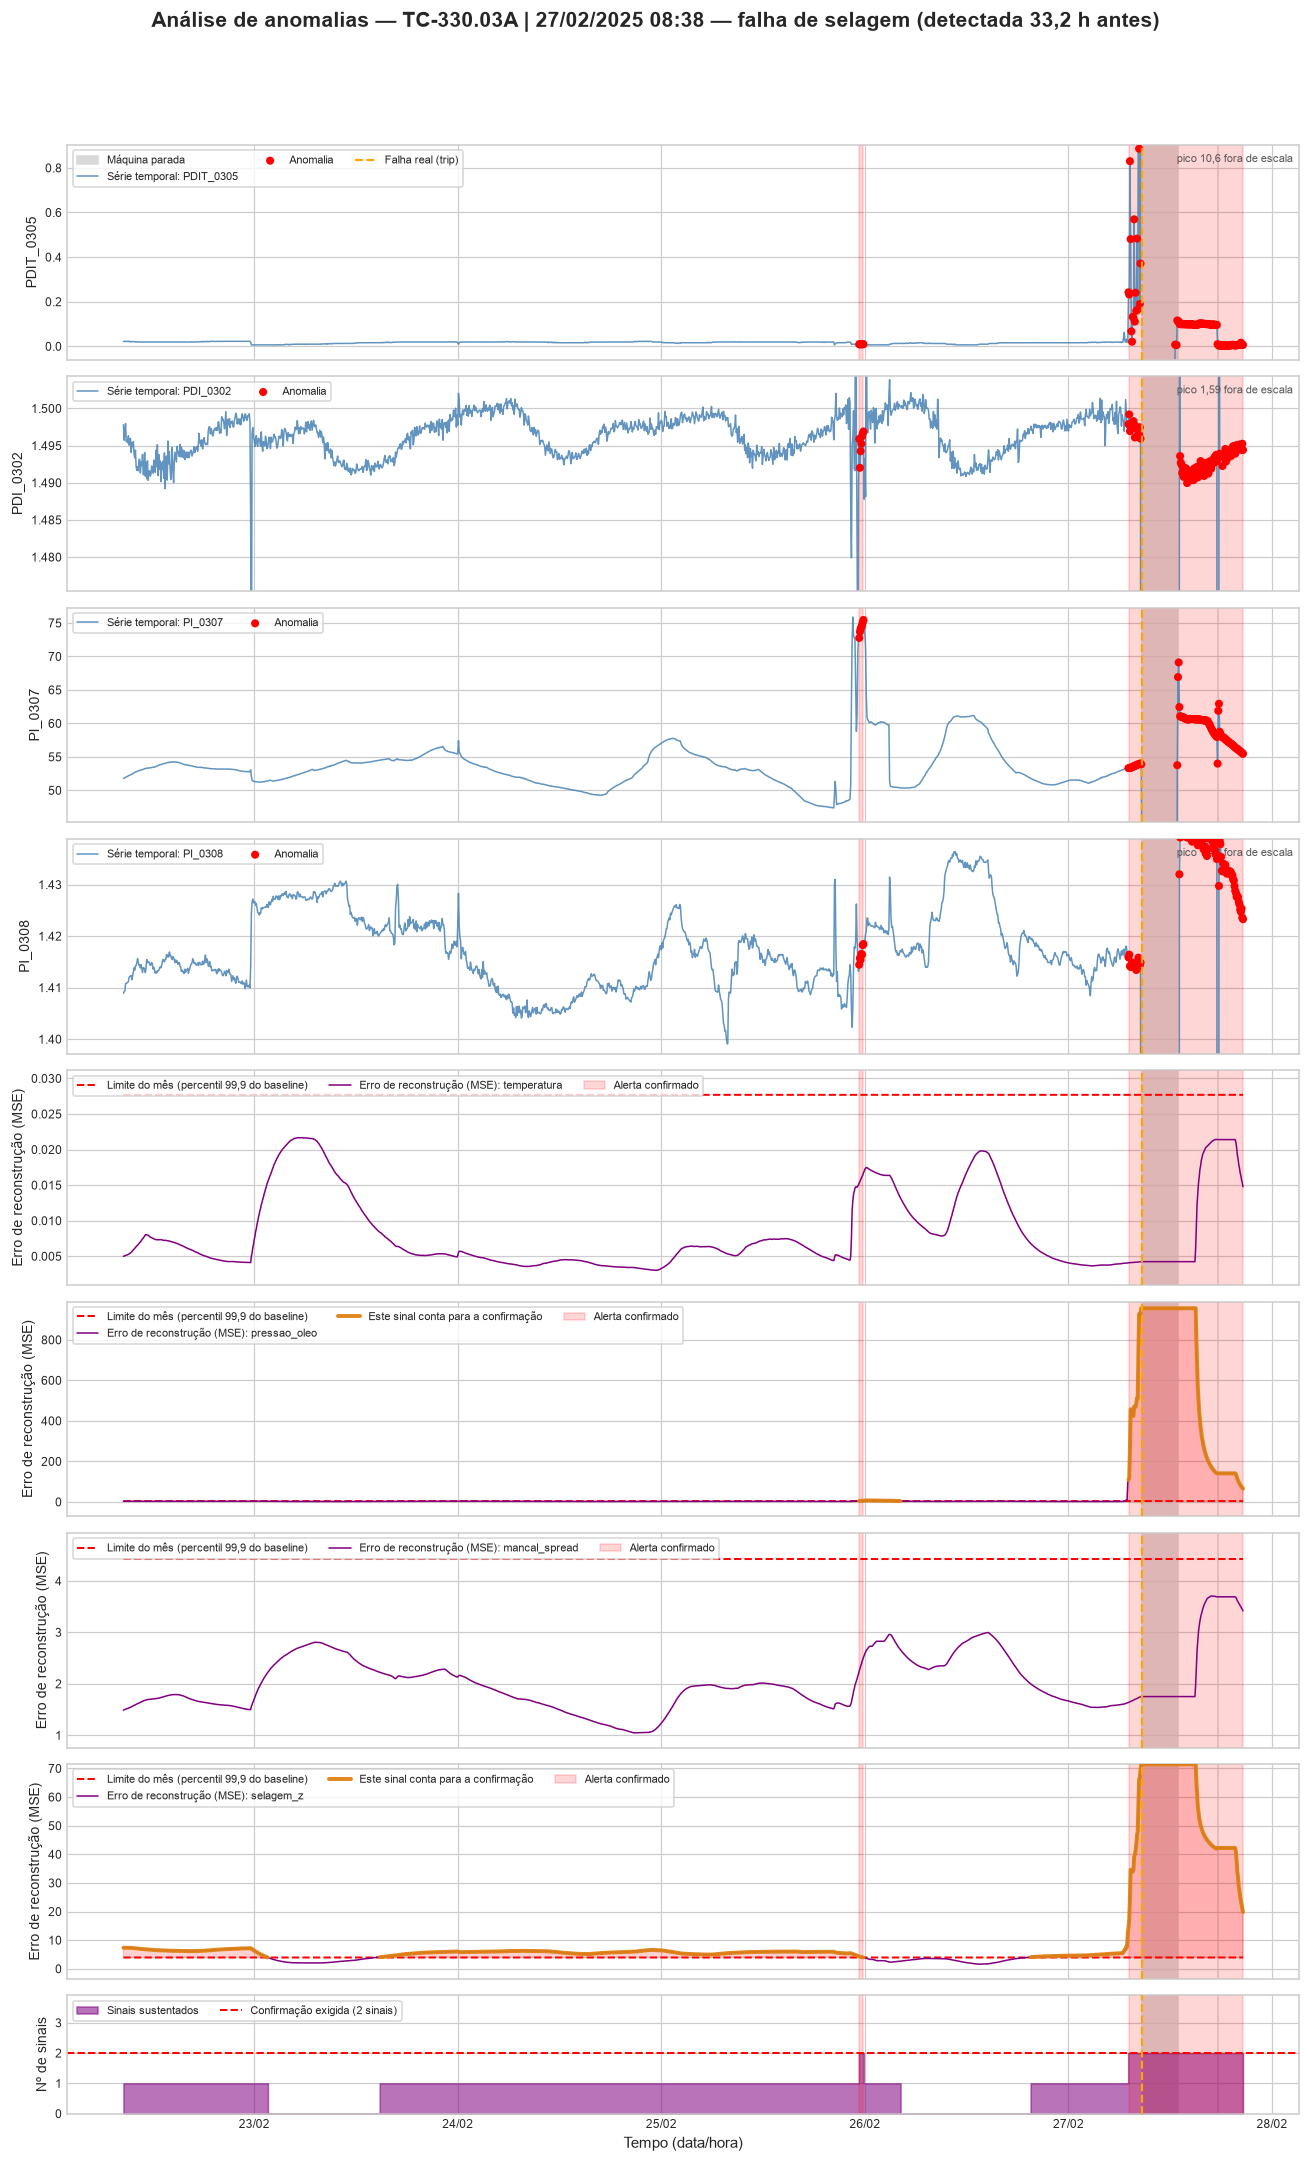

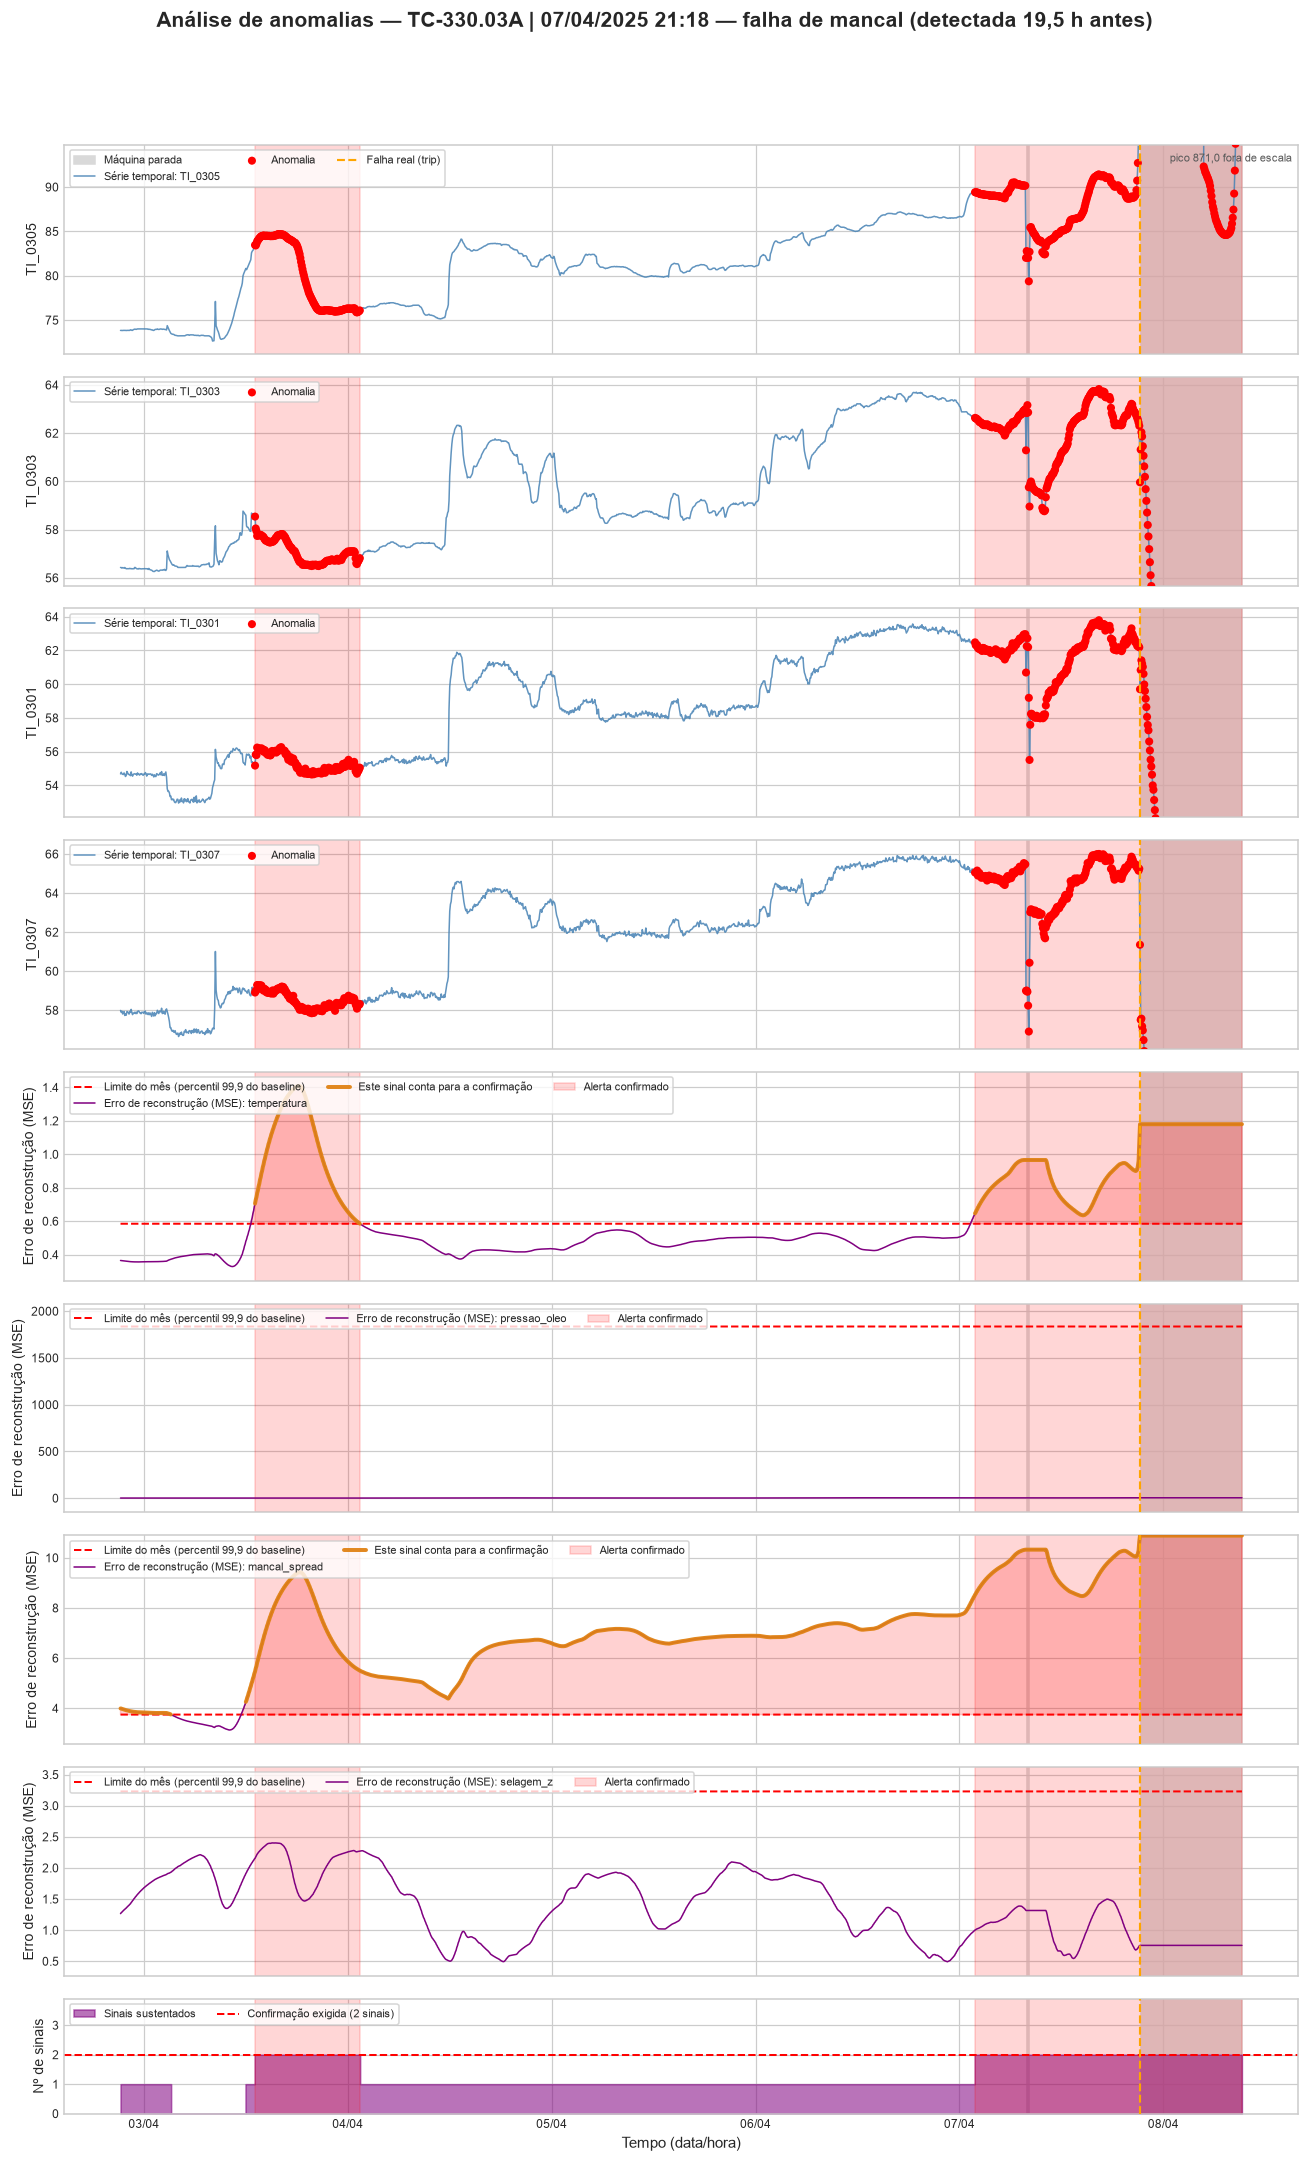

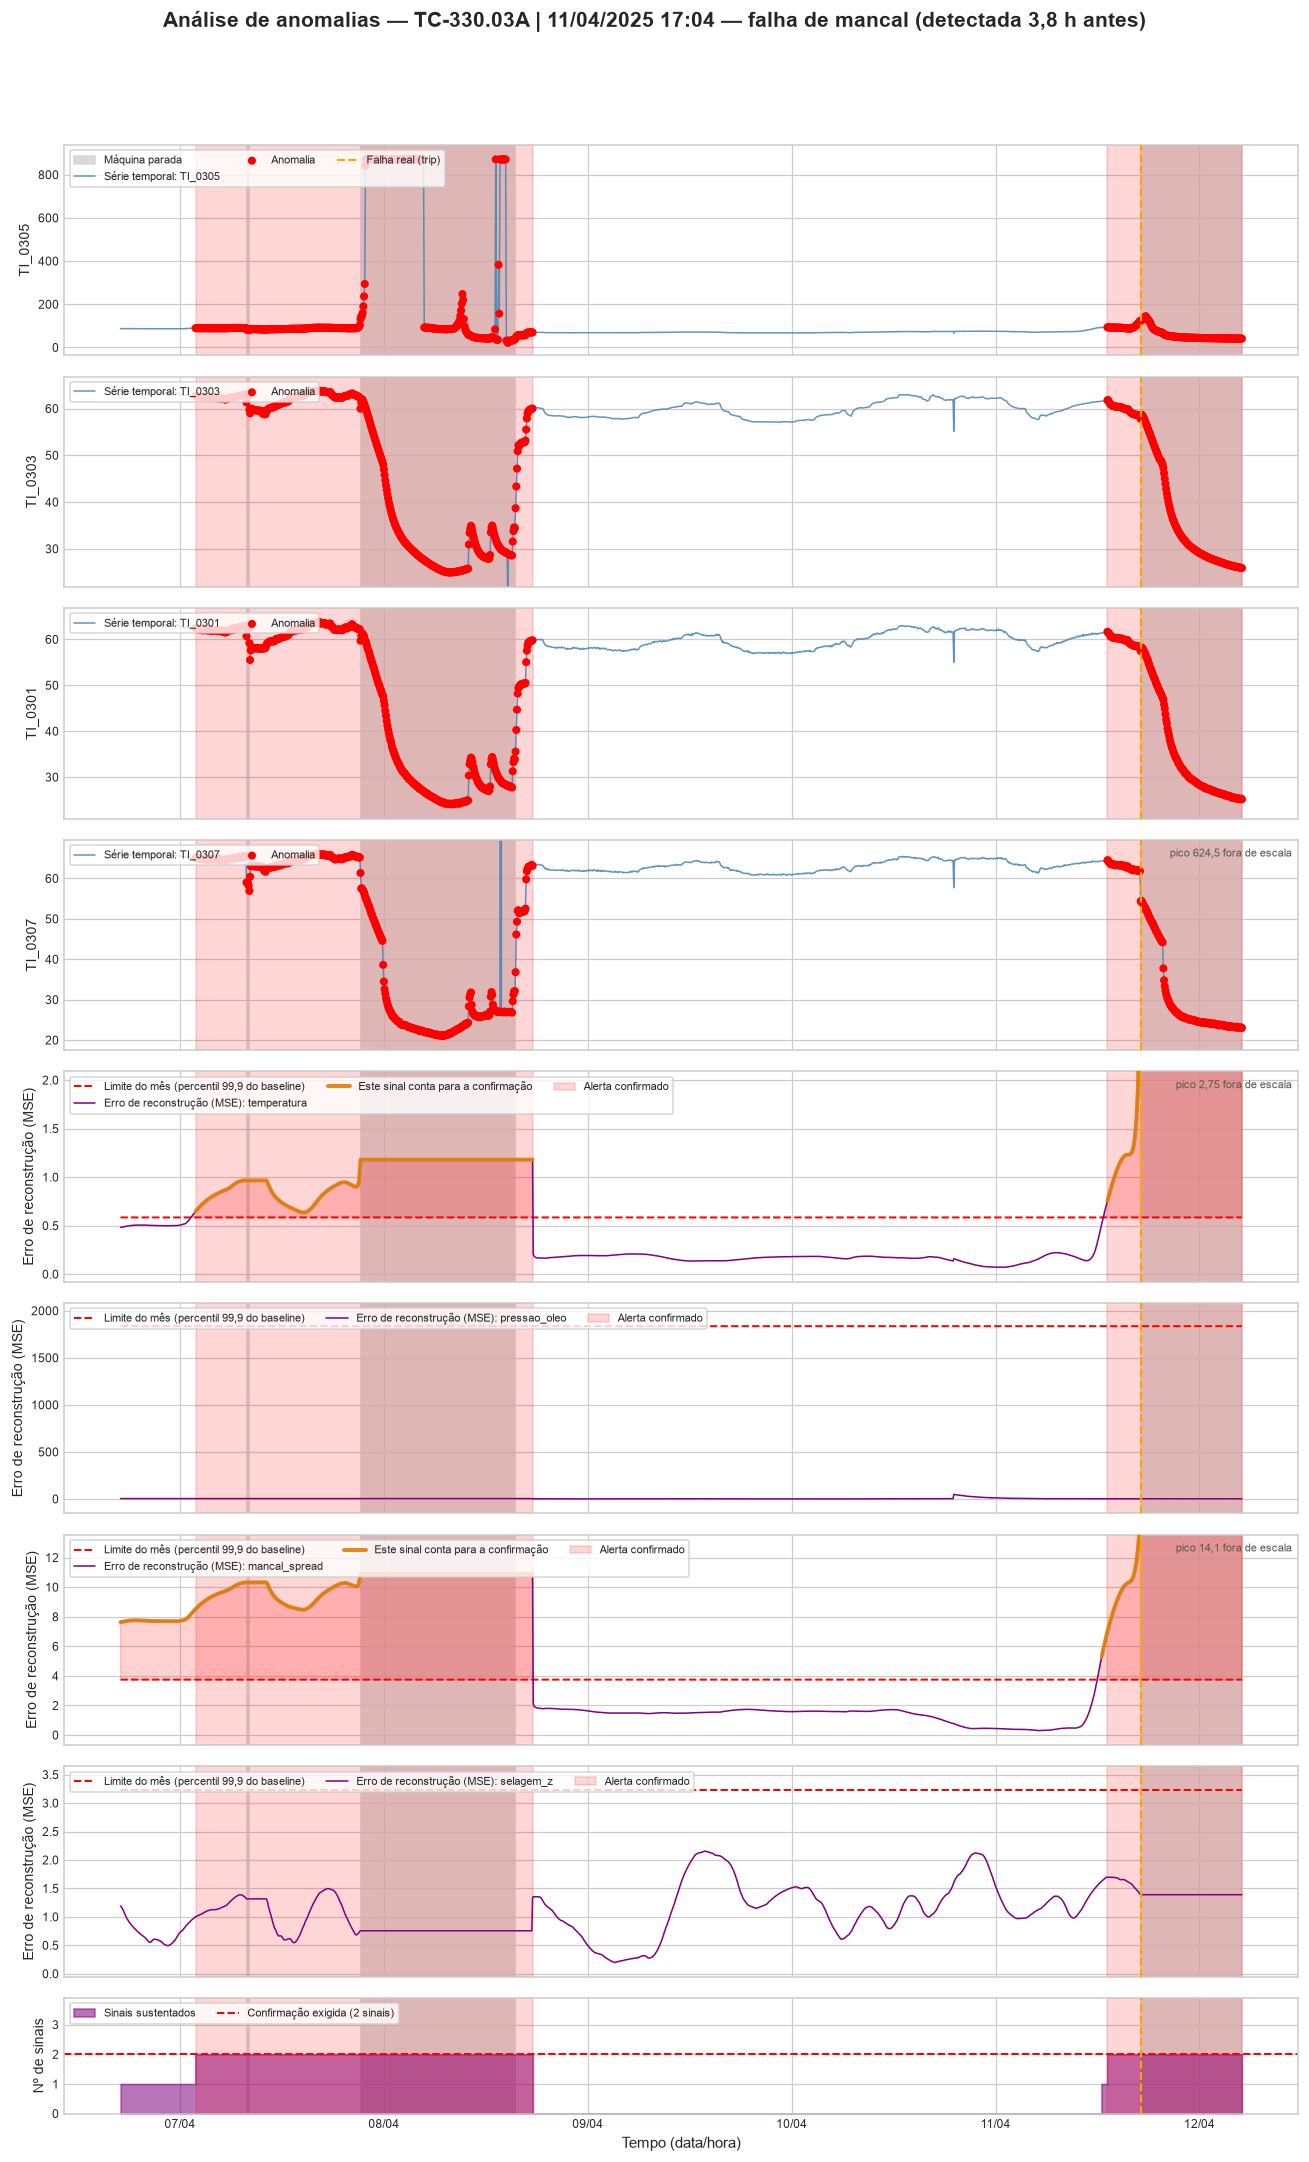

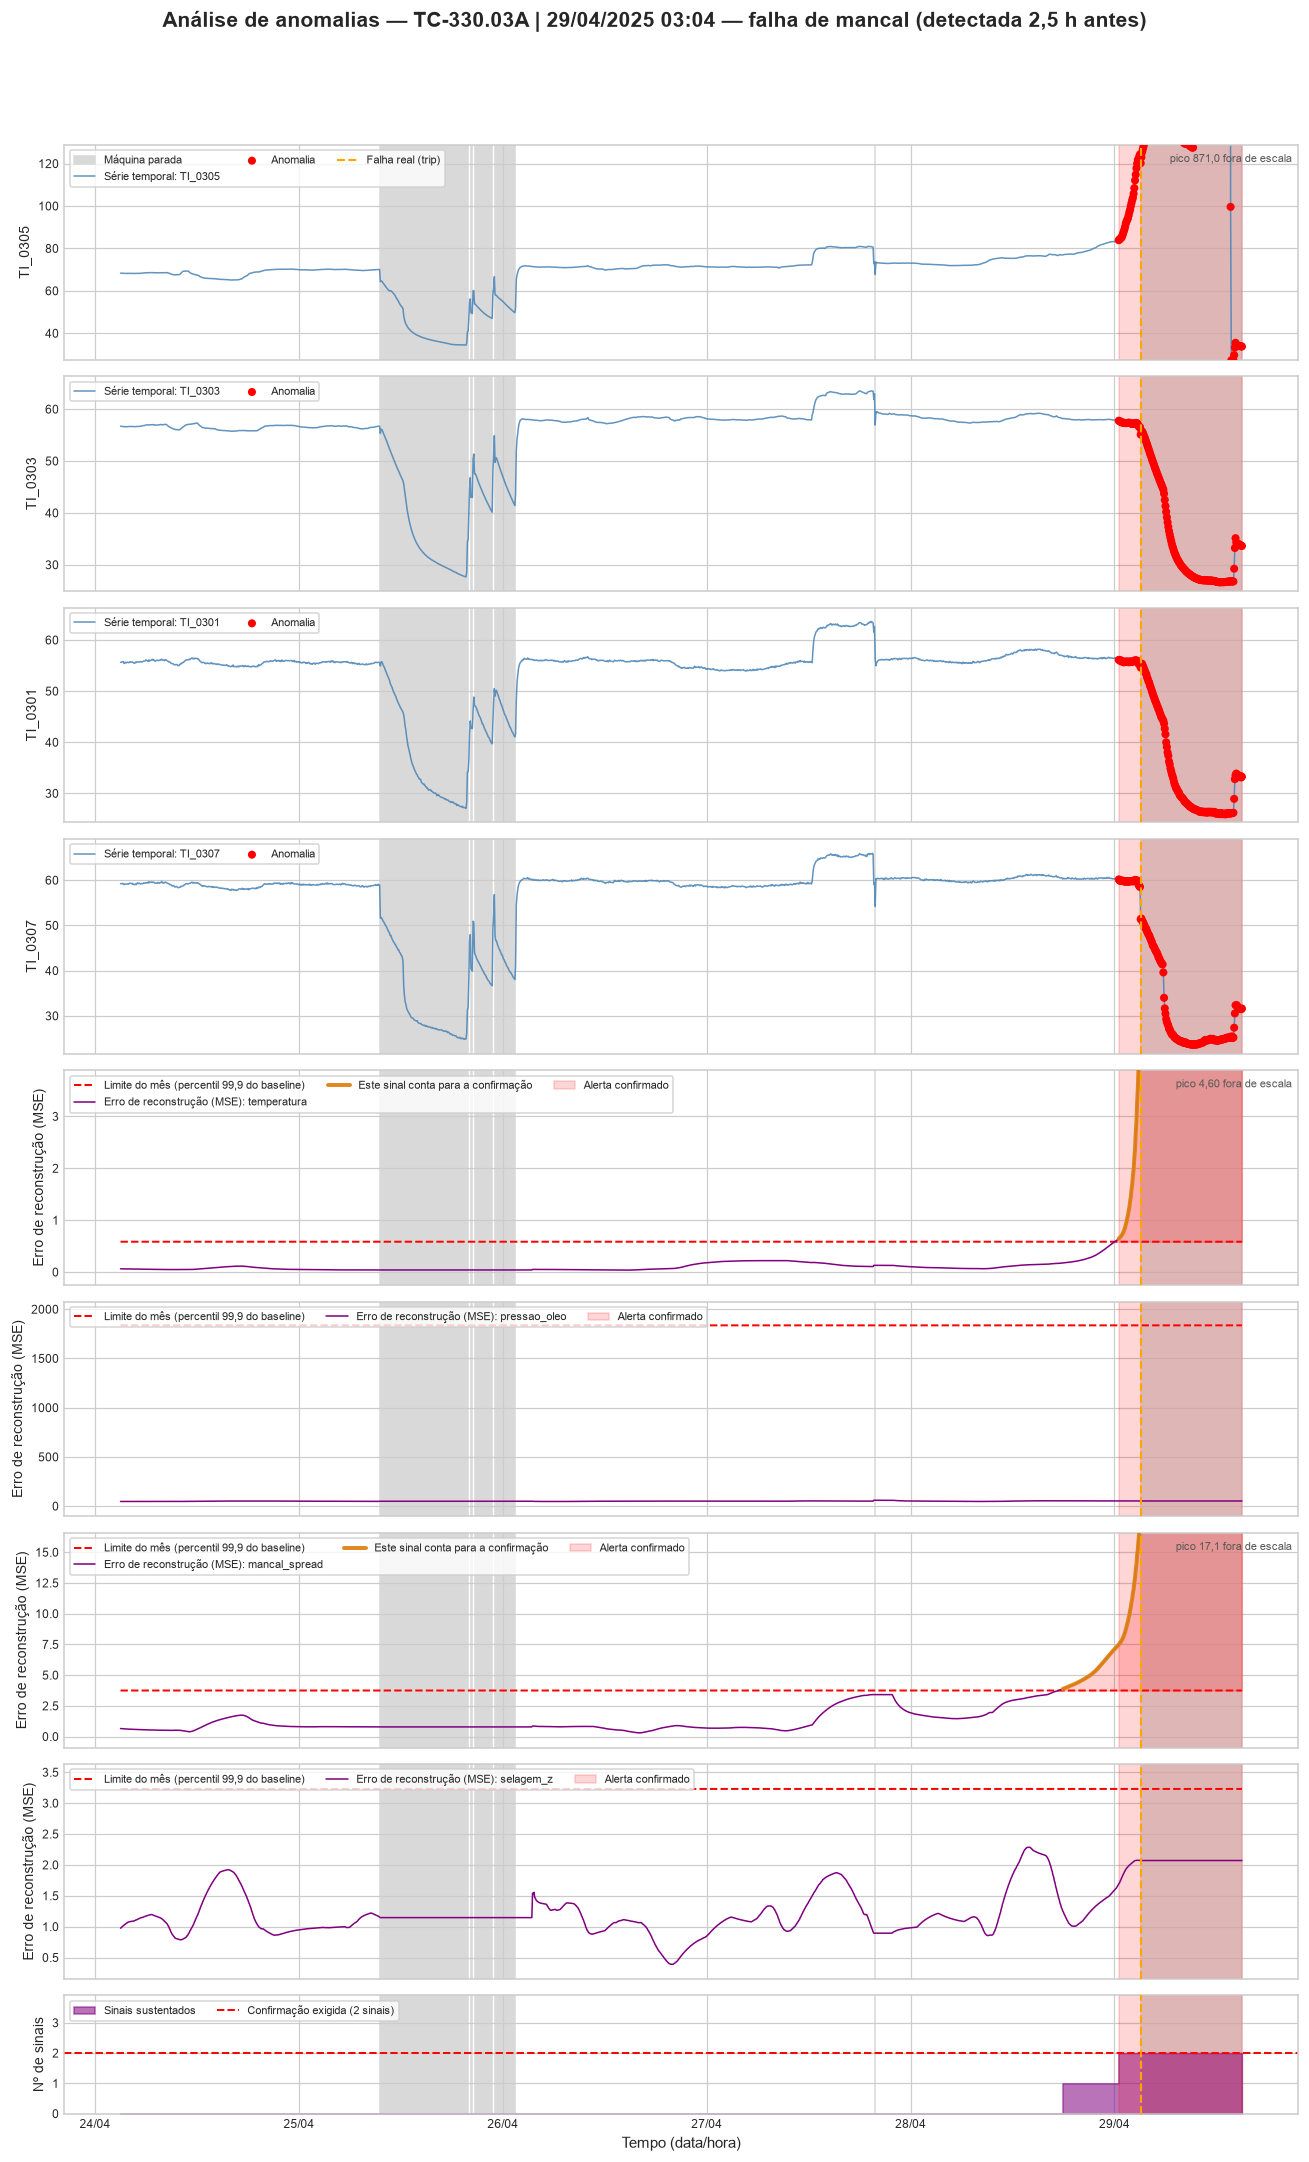

In [11]:
resultado_op = replay.run(**OPERACIONAL)
viz.plot_placar(resultado_op)

ganhos = [e for e in resultado_op.events if e["detectada"]
          and not next(x for x in resultado.events if x["inicio"] == e["inicio"])["detectada"]]
for evento in ganhos:
    viz.plot_evento(resultado_op, evento)
print("falhas que só o ponto operacional antecipa:",
      [f"{e['inicio']:%d/%m/%Y} ({e['mecanismo']}, {e['lead_h']} h)" for e in ganhos] or "nenhuma")

## Ressalvas

1. **"Não detectada" significa "sem alerta nas 48 h anteriores"** — janela de
   detecção fixada pelo AutoML. Cinco das seis falhas tinham a máquina ligada
   praticamente a janela inteira, então as perdas são perdas de fato; a exceção é
   04/11/2025, com apenas ~15 h de operação na janela.
2. **Falso positivo aqui é contado de forma conservadora**: episódios que
   precedem uma parada da máquina (mesmo sem trip catalogado) não entram como
   falso alarme, porque não se sabe se a parada foi consequência do que o modelo
   viu. São os triângulos laranja da figura 1 — cinco deles no período.
3. **Vibração está fora.** O normal dela não se sustenta entre meses e geraria
   falso positivo crescente; segue em quarentena como sinal de alarme.
4. **`NGP_A` não existe nesta versão do dataset**, então a operabilidade vem de
   `RUNNING_A ≥ 0,5` com exclusão de 2 h após cada partida. Isso não afeta as
   figuras (o sombreado cinza confere com as paradas conhecidas), mas segue como
   pendência para o resíduo condicionado à carga.